# Customer Segmentation & Cohort Analysis
## UCI Online Retail Dataset — End-to-End Portfolio Project

**Author:** Jordan Shamukiga  
**Dataset:** [UCI Online Retail Dataset](https://archive.ics.uci.edu/ml/datasets/Online+Retail) (also on [Kaggle](https://www.kaggle.com/datasets/vijayuv/onlineretail))  
**Tools:** Python | Pandas | Scikit-learn | Matplotlib | Seaborn  
**GitHub:** https://github.com/jordanshamu

---

## Project Overview

This project performs a complete customer analytics lifecycle on a real-world UK e-commerce dataset containing **~500,000 transactions** across **4,300+ customers** and **38 countries**:

1. **Exploratory Data Analysis** — understand purchasing patterns, revenue drivers, and customer geography
2. **RFM Analysis** — score customers on Recency, Frequency, and Monetary value; assign business segments
3. **K-Means Clustering** — data-driven customer grouping with optimal K selection (elbow + silhouette + Davies-Bouldin)
4. **Cohort Analysis** — track retention rates and revenue trends across acquisition cohorts
5. **Customer Lifetime Value (CLV)** — estimate discounted CLV and tier customers by long-term value
6. **Business Recommendations** — actionable, segment-specific strategies with estimated ROI

---

## Business Questions

1. Who are our most valuable customers, and what are their behavioral signatures?
2. Are we retaining customers over time, or suffering high churn?
3. Which customer groups are at risk of churning, and how should we respond?
4. What is the projected lifetime value of our customer base?
5. Where should we focus marketing investment for maximum return?

---

## Dataset

| Field | Description |
|-------|-------------|
| `InvoiceNo` | Invoice number (starts with 'C' = cancelled) |
| `StockCode` | Product code |
| `Description` | Product name |
| `Quantity` | Number of units per transaction |
| `InvoiceDate` | Invoice date and time |
| `UnitPrice` | Price per unit (GBP) |
| `CustomerID` | Unique customer identifier |
| `Country` | Country of the customer |

**Download the dataset from Kaggle:** https://www.kaggle.com/datasets/vijayuv/onlineretail  
Place `OnlineRetail.csv` in the `data/raw/` folder before running.


---
## Section 1: Setup & Configuration

In [1]:
# ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
import sys
import os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), 'src'))
# If running from notebooks/ directory:
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score
from scipy import stats
import warnings
import json
from datetime import datetime

# Import our utility functions
from utils import (
    set_plot_style, load_online_retail_data, clean_retail_data,
    compute_rfm, score_rfm, assign_rfm_segment, rfm_segment_summary,
    prepare_features_for_clustering, find_optimal_clusters, fit_kmeans, cluster_profile,
    build_cohort_data, compute_cohort_revenue,
    compute_clv, describe_rfm_stats, kruskal_test_across_clusters,
    save_figure, export_metrics, print_section, format_currency,
    SEGMENT_COLORS, CLUSTER_PALETTE
)

warnings.filterwarnings('ignore')
set_plot_style()

# Paths
DATA_RAW  = '../data/raw/OnlineRetail.csv'
DATA_PROC = '../data/processed/rfm_segmented.csv'
VIZ_DIR   = '../visualizations/'
REPORTS   = '../reports/'

print("✅ Setup complete")
print(f"   Python: {sys.version.split()[0]}")
print(f"   Pandas: {pd.__version__}")
print(f"   Numpy:  {np.__version__}")


✅ Setup complete
   Python: 3.10.9
   Pandas: 2.3.1
   Numpy:  2.1.3


---
## Section 2: Data Loading & Quality Assessment

In [2]:
# ─────────────────────────────────────────────
# LOAD DATA
# ─────────────────────────────────────────────
df_raw = load_online_retail_data(DATA_RAW)
df_raw.head()


Loaded 541,909 rows x 8 columns
   Date range: 2010-12-01 to 2011-12-09


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [3]:
# ─────────────────────────────────────────────
# INITIAL QUALITY INSPECTION
# ─────────────────────────────────────────────
print("=== SHAPE ===")
print(f"Rows: {df_raw.shape[0]:,}  |  Columns: {df_raw.shape[1]}")

print("\n=== COLUMN TYPES ===")
print(df_raw.dtypes)

print("\n=== MISSING VALUES ===")
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
print(pd.DataFrame({'Missing': missing, 'Pct': missing_pct})[missing > 0])

print("\n=== DUPLICATES ===")
print(f"Exact duplicate rows: {df_raw.duplicated().sum():,}")

print("\n=== SAMPLE STATS ===")
print(df_raw[['Quantity', 'UnitPrice']].describe())


=== SHAPE ===
Rows: 541,909  |  Columns: 8

=== COLUMN TYPES ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

=== MISSING VALUES ===
             Missing    Pct
Description     1454   0.27
CustomerID    135080  24.93

=== DUPLICATES ===
Exact duplicate rows: 5,268

=== SAMPLE STATS ===
            Quantity      UnitPrice
count  541909.000000  541909.000000
mean        9.552250       4.611114
std       218.081158      96.759853
min    -80995.000000  -11062.060000
25%         1.000000       1.250000
50%         3.000000       2.080000
75%        10.000000       4.130000
max     80995.000000   38970.000000


In [4]:
# ─────────────────────────────────────────────
# CLEAN DATA
# ─────────────────────────────────────────────
df, quality_report = clean_retail_data(df_raw)

print("\n=== FINAL CLEANED DATASET ===")
print(f"  Customers: {df['CustomerID'].nunique():,}")
print(f"  Invoices:  {df['InvoiceNo'].nunique():,}")
print(f"  Products:  {df['StockCode'].nunique():,}")
print(f"  Countries: {df['Country'].nunique():,}")
print(f"  Revenue:   GBP {df['TotalRevenue'].sum():,.0f}")
print(f"  Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")


Cleaning complete: 396,470 rows retained (73.2%)

=== FINAL CLEANED DATASET ===
  Customers: 4,334
  Invoices:  18,405
  Products:  3,660
  Countries: 37
  Revenue:   GBP 8,767,753
  Date range: 2010-12-01 to 2011-12-09


---
## Section 3: Exploratory Data Analysis (EDA)

   Saved: ../visualizations/monthly_performance.png


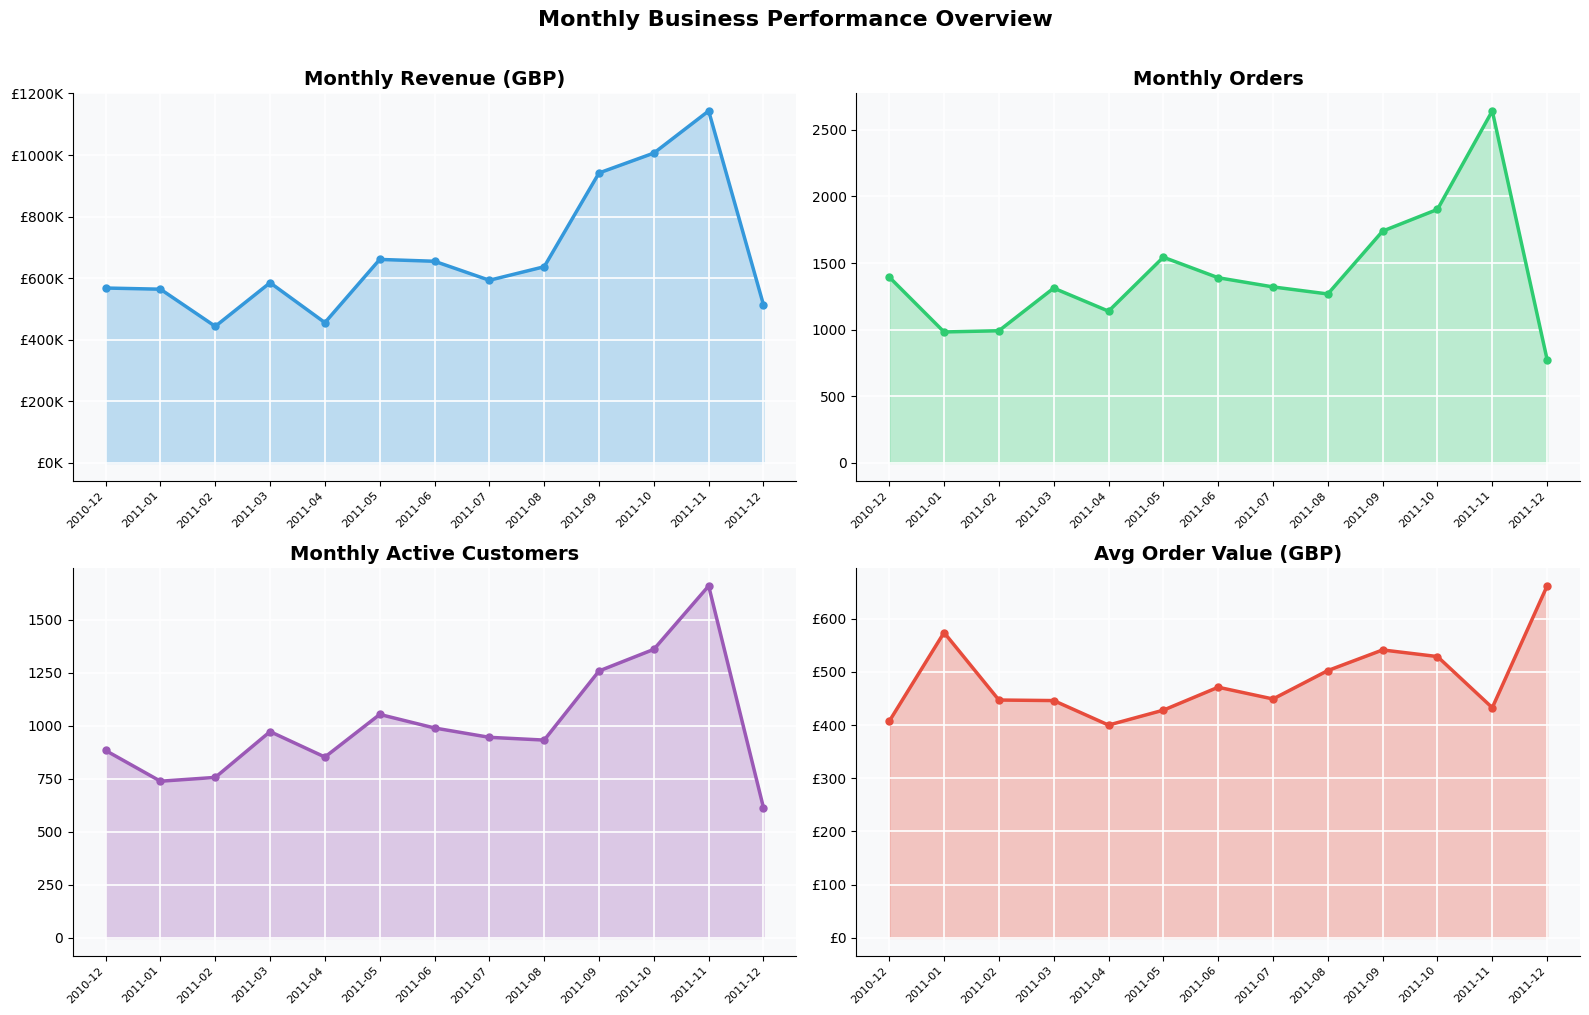

In [5]:
# ─────────────────────────────────────────────
# REVENUE TRENDS: MONTHLY
# ─────────────────────────────────────────────
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly = df.groupby('YearMonth').agg(
    Revenue  =('TotalRevenue', 'sum'),
    Orders   =('InvoiceNo', 'nunique'),
    Customers=('CustomerID', 'nunique')
).reset_index()
monthly['YearMonth_str'] = monthly['YearMonth'].astype(str)
monthly['Avg_Order_Value'] = monthly['Revenue'] / monthly['Orders']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Monthly Business Performance Overview', fontsize=16, fontweight='bold', y=1.01)

# Revenue
ax = axes[0, 0]
ax.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.3, color='#3498db')
ax.plot(range(len(monthly)), monthly['Revenue'], color='#3498db', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Monthly Revenue (GBP)')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_xlabel('')

# Orders
ax = axes[0, 1]
ax.fill_between(range(len(monthly)), monthly['Orders'], alpha=0.3, color='#2ecc71')
ax.plot(range(len(monthly)), monthly['Orders'], color='#2ecc71', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Monthly Orders')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)

# Unique Customers
ax = axes[1, 0]
ax.fill_between(range(len(monthly)), monthly['Customers'], alpha=0.3, color='#9b59b6')
ax.plot(range(len(monthly)), monthly['Customers'], color='#9b59b6', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Monthly Active Customers')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)

# Avg Order Value
ax = axes[1, 1]
ax.fill_between(range(len(monthly)), monthly['Avg_Order_Value'], alpha=0.3, color='#e74c3c')
ax.plot(range(len(monthly)), monthly['Avg_Order_Value'], color='#e74c3c', linewidth=2.5, marker='o', markersize=5)
ax.set_title('Avg Order Value (GBP)')
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(monthly['YearMonth_str'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:.0f}'))

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'monthly_performance.png')
plt.show()


**Analyst note on November 2011 spike:** The monthly revenue chart above shows a pronounced spike in November 2011 — roughly 2× the average month. Given that this is a gift and homeware retailer, I'm almost certain this reflects holiday pre-ordering (Christmas, Black Friday). I considered excluding it to avoid inflating "average monthly revenue" figures, but decided against it: removing November would misrepresent the business's actual revenue pattern, which genuinely is seasonal. I'm keeping it in the dataset, but it's worth flagging — any metric described as a "monthly average" in this analysis is pulled upward by that November spike. If I were building a forecasting model, I'd handle this with a seasonal component rather than an exclusion.

   Saved: ../visualizations/geographic_distribution.png


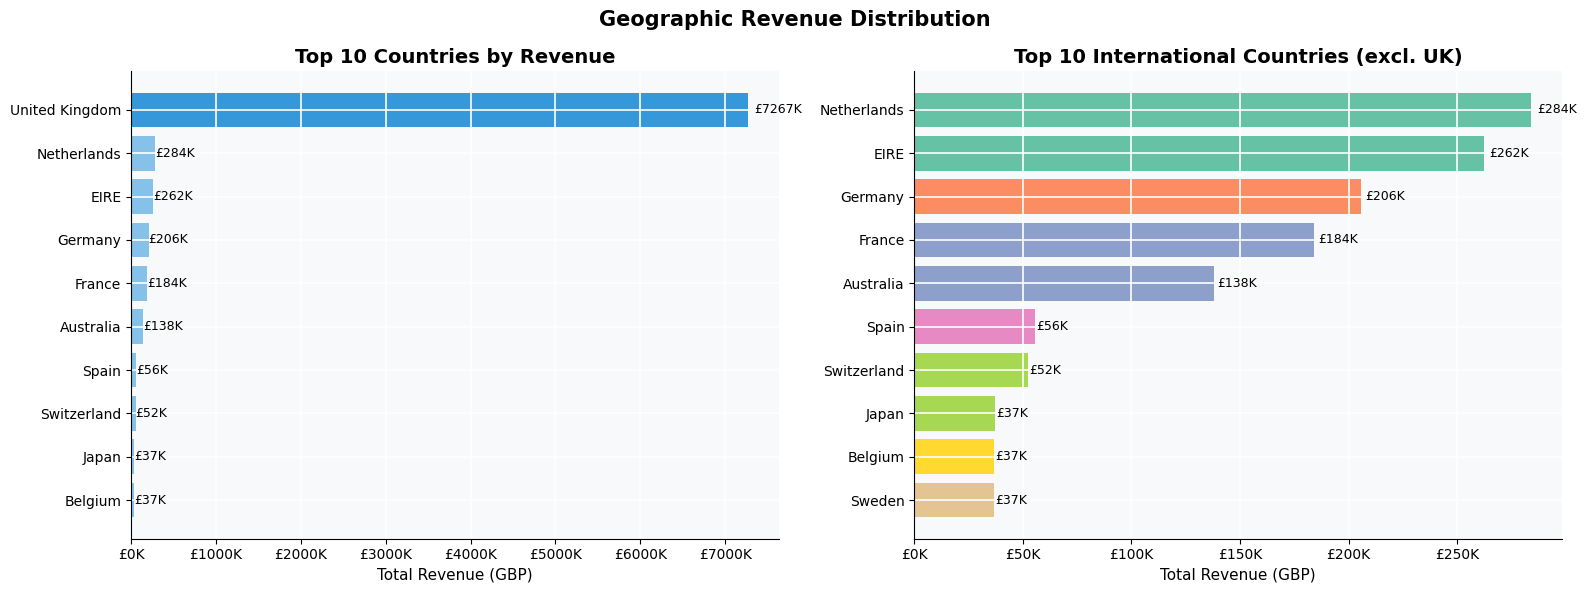


UK Revenue: GBP 7,267,337 (82.9% of total)
International Revenue: GBP 1,500,415


In [6]:
# ─────────────────────────────────────────────
# TOP COUNTRIES BY REVENUE
# ─────────────────────────────────────────────
country_rev = df.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False)
top_countries = country_rev.head(10)

# Exclude UK to see international distribution
intl = country_rev.drop('United Kingdom', errors='ignore').head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Geographic Revenue Distribution', fontsize=15, fontweight='bold')

# All countries
ax = axes[0]
bars = ax.barh(top_countries.index[::-1], top_countries.values[::-1],
               color=['#3498db' if c == 'United Kingdom' else '#85c1e9' for c in top_countries.index[::-1]])
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Top 10 Countries by Revenue')
ax.set_xlabel('Total Revenue (GBP)')
for bar, val in zip(bars, top_countries.values[::-1]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'£{val/1000:.0f}K', va='center', fontsize=9)

# International only
ax = axes[1]
colors = plt.cm.Set2(np.linspace(0, 0.8, len(intl)))
bars = ax.barh(intl.index[::-1], intl.values[::-1], color=colors[::-1])
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Top 10 International Countries (excl. UK)')
ax.set_xlabel('Total Revenue (GBP)')
for bar, val in zip(bars, intl.values[::-1]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'£{val/1000:.0f}K', va='center', fontsize=9)

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'geographic_distribution.png')
plt.show()

print(f"\nUK Revenue: GBP {country_rev.get('United Kingdom', 0):,.0f} ({country_rev.get('United Kingdom', 0)/country_rev.sum()*100:.1f}% of total)")
print(f"International Revenue: GBP {country_rev.drop('United Kingdom', errors='ignore').sum():,.0f}")


   Saved: ../visualizations/top_products.png


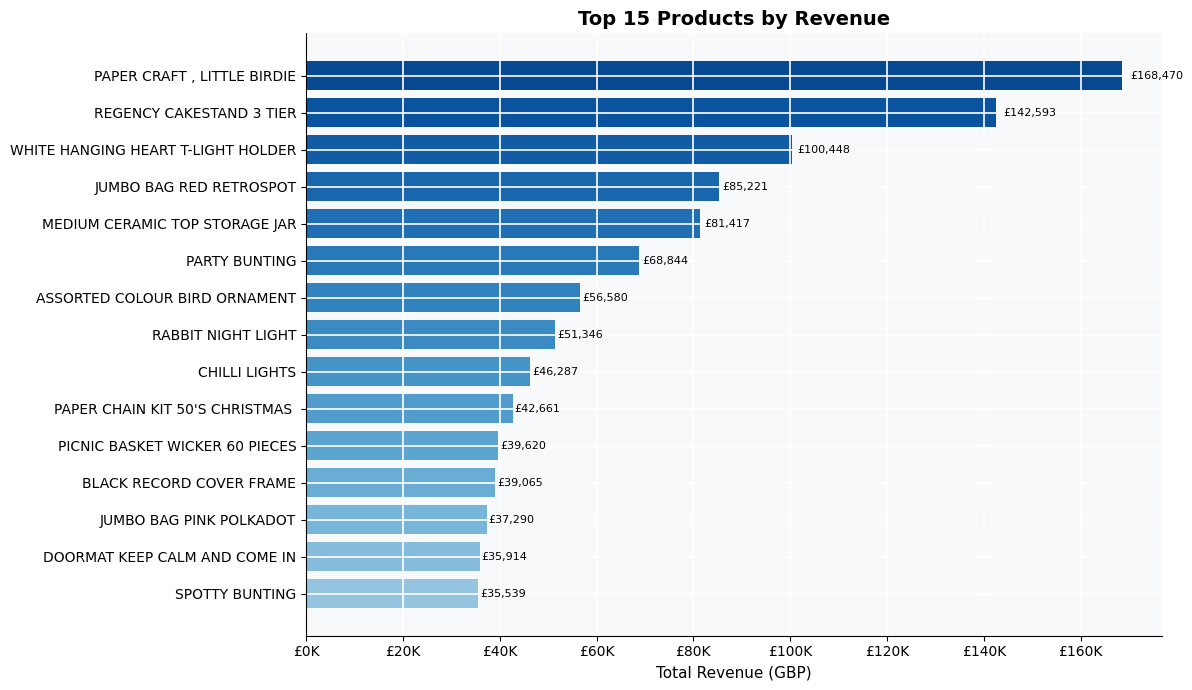


Top product accounts for 1.9% of total revenue


In [7]:
# ─────────────────────────────────────────────
# TOP PRODUCTS
# ─────────────────────────────────────────────
top_products = (
    df.groupby('Description')
      .agg(Revenue=('TotalRevenue', 'sum'), Orders=('InvoiceNo', 'nunique'))
      .sort_values('Revenue', ascending=False)
      .head(15)
)

fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(top_products)))
bars = ax.barh(top_products.index[::-1], top_products['Revenue'].values[::-1], color=colors)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Top 15 Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Revenue (GBP)')
for bar, val in zip(bars, top_products['Revenue'].values[::-1]):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=8)
plt.tight_layout()
save_figure(fig, VIZ_DIR + 'top_products.png')
plt.show()

print(f"\nTop product accounts for {top_products['Revenue'].iloc[0]/df['TotalRevenue'].sum()*100:.1f}% of total revenue")


   Saved: ../visualizations/temporal_patterns.png


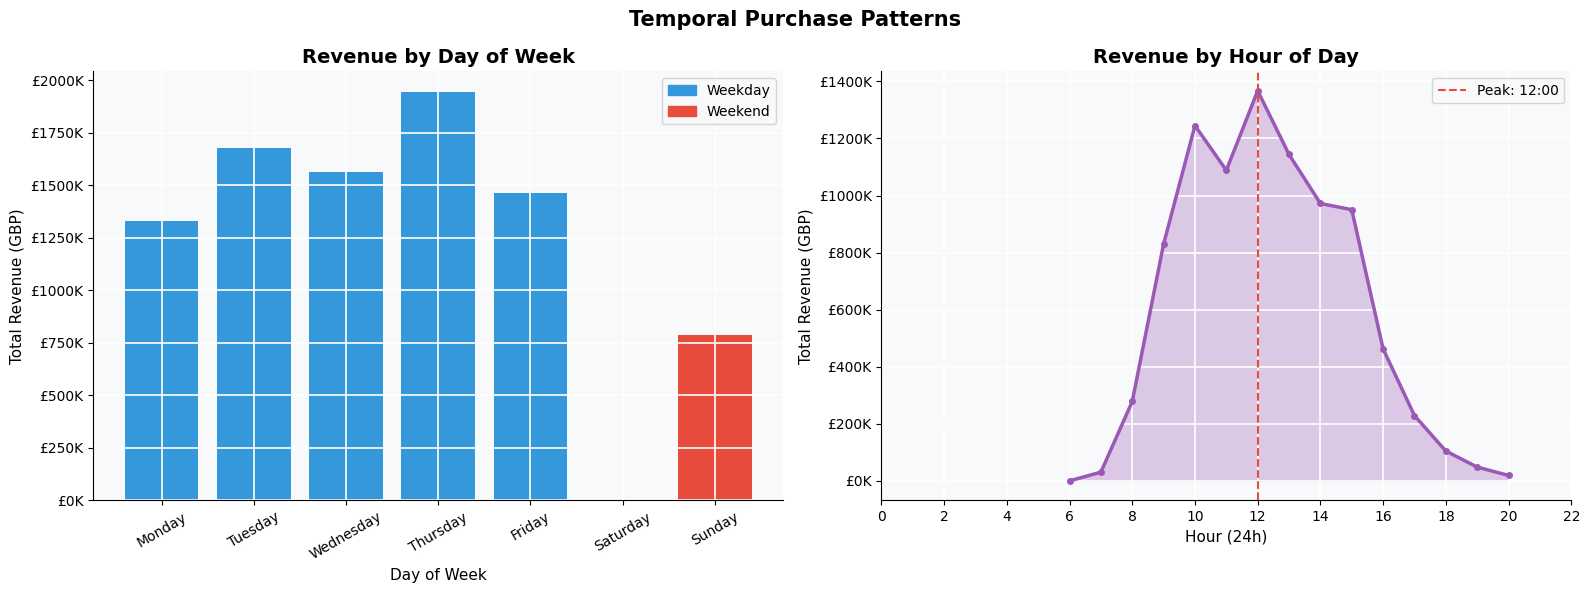

Peak revenue day: Thursday (GBP 1,944,933)
Peak revenue hour: 12:00


In [8]:
# ─────────────────────────────────────────────
# PURCHASE BEHAVIOR: DAY OF WEEK & HOUR
# ─────────────────────────────────────────────
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()
df['Hour'] = df['InvoiceDate'].dt.hour

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_data = df.groupby('DayOfWeek').agg(
    Revenue=('TotalRevenue', 'sum'),
    Orders =('InvoiceNo', 'nunique')
).reindex(day_order)

hour_data = df.groupby('Hour').agg(
    Revenue=('TotalRevenue', 'sum'),
    Orders =('InvoiceNo', 'nunique')
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Temporal Purchase Patterns', fontsize=15, fontweight='bold')

# Day of week
ax = axes[0]
colors_day = ['#e74c3c' if d in ['Saturday', 'Sunday'] else '#3498db' for d in day_order]
bars = ax.bar(day_order, day_data['Revenue'], color=colors_day)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Revenue by Day of Week')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Revenue (GBP)')
ax.tick_params(axis='x', rotation=30)
patches = [mpatches.Patch(color='#3498db', label='Weekday'),
           mpatches.Patch(color='#e74c3c', label='Weekend')]
ax.legend(handles=patches)

# Hour of day
ax = axes[1]
ax.fill_between(hour_data.index, hour_data['Revenue'], alpha=0.3, color='#9b59b6')
ax.plot(hour_data.index, hour_data['Revenue'], color='#9b59b6', linewidth=2.5, marker='o', markersize=4)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Revenue by Hour of Day')
ax.set_xlabel('Hour (24h)')
ax.set_ylabel('Total Revenue (GBP)')
ax.set_xticks(range(0, 24, 2))
peak_hour = hour_data['Revenue'].idxmax()
ax.axvline(peak_hour, color='#e74c3c', linestyle='--', linewidth=1.5, label=f'Peak: {peak_hour}:00')
ax.legend()

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'temporal_patterns.png')
plt.show()

print(f"Peak revenue day: {day_data['Revenue'].idxmax()} (GBP {day_data['Revenue'].max():,.0f})")
print(f"Peak revenue hour: {peak_hour}:00")


---
## Section 4: RFM Analysis

**RFM** is a proven customer value framework used across retail, subscription, and e-commerce:

| Metric | Definition | Business Meaning |
|--------|-----------|-----------------|
| **Recency** | Days since last purchase | Are they still engaged? |
| **Frequency** | Number of unique orders | How loyal are they? |
| **Monetary** | Total spend | How valuable are they? |

Each customer is scored 1–5 on each dimension, then segmented into named business groups.


In [9]:
# ─────────────────────────────────────────────
# COMPUTE RFM
# ─────────────────────────────────────────────

# compute_rfm uses nunique() on InvoiceNo for Frequency rather than row count,
# because a single invoice can contain many line items — counting rows would
# conflate large-basket buyers with frequent repeat buyers.
rfm = compute_rfm(df)

# score_rfm uses quintile scoring (pd.qcut, 5 bins) rather than fixed thresholds
# because the RFM distributions are highly skewed. Fixed thresholds (e.g. "top 20%
# by spend") would produce very uneven bin sizes. Quintiles guarantee each score
# bucket has ~20% of customers, which keeps downstream segment sizes interpretable.
# Internally, rank(method='first') is applied before qcut on F and M to break ties —
# without it, qcut fails when >20% of customers share the same value (common in F).
rfm = score_rfm(rfm)
rfm = assign_rfm_segment(rfm)
rfm = compute_clv(rfm, avg_lifespan_years=3, discount_rate=0.10)

print("\nRFM sample:")
rfm.head()


RFM computed for 4,334 customers (snapshot: 2011-12-10)
CLV computed (lifespan=3yr, discount=10%)

RFM sample:


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment,Avg_Order_Value,Annual_Revenue,CLV_Simple,CLV_Discounted,CLV_Tier
0,12346,326,1,77183.60,1,1,5,115,7,Lost,77183.600000,77183.60,231550.80,191944.189331,Platinum
1,12347,2,7,4310.00,5,5,5,555,15,Champions,615.714286,4310.00,12930.00,10718.332081,Platinum
2,12348,75,4,1437.24,2,4,4,244,10,At Risk,359.310000,1437.24,4311.72,3574.203156,Gold
3,12349,19,1,1457.55,4,1,4,414,9,Recent Customers,1457.550000,1457.55,4372.65,3624.711119,Gold
4,12350,310,1,294.40,1,1,2,112,4,Lost,294.400000,294.40,883.20,732.129226,Bronze


   Saved: ../visualizations/rfm_distributions.png


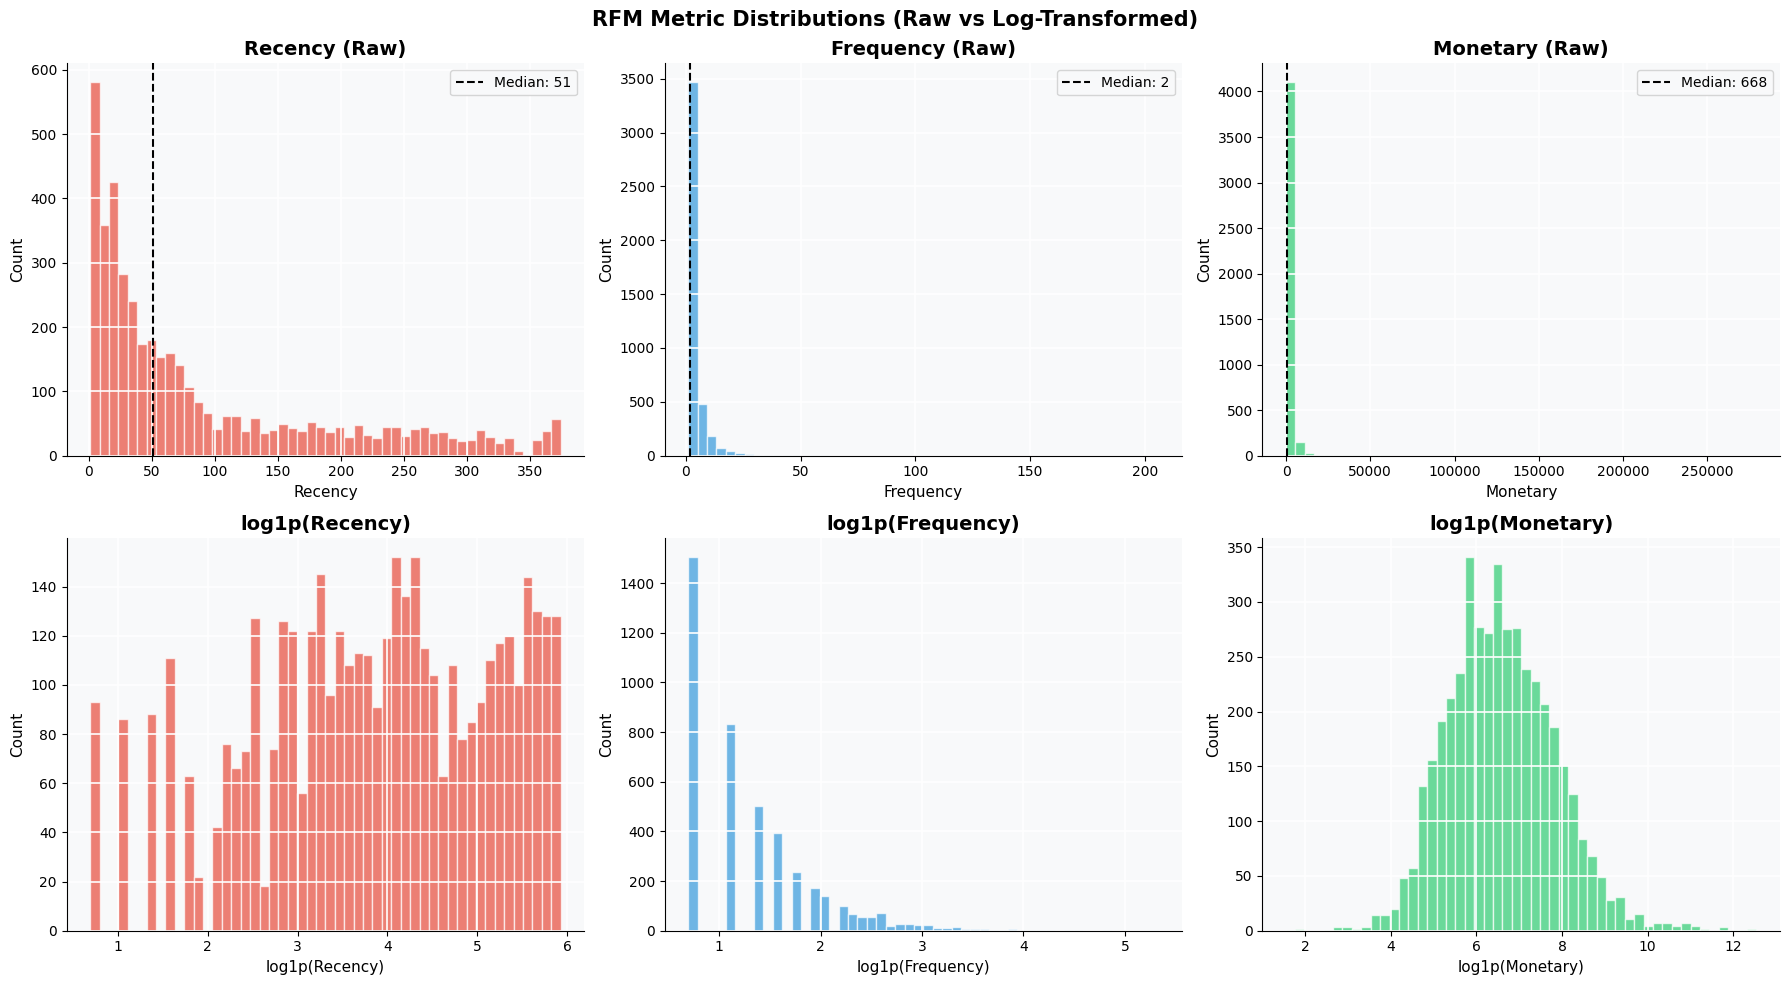


RFM Descriptive Statistics:
          Recency  Frequency   Monetary
count     4334.00    4334.00    4334.00
mean        92.70       4.25    2023.02
std        100.18       7.64    8924.20
min          1.00       1.00       3.75
25%         18.00       1.00     305.87
50%         51.00       2.00     668.12
75%        143.00       5.00    1631.62
max        374.00     206.00  279138.02
skewness     1.24      11.98      19.54
kurtosis     0.42     245.21     487.32


In [10]:
# ─────────────────────────────────────────────
# RFM DISTRIBUTIONS
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('RFM Metric Distributions (Raw vs Log-Transformed)', fontsize=15, fontweight='bold')

metrics = ['Recency', 'Frequency', 'Monetary']
colors  = ['#e74c3c', '#3498db', '#2ecc71']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    # Raw
    ax = axes[0, i]
    ax.hist(rfm[metric], bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'{metric} (Raw)')
    ax.set_xlabel(metric)
    ax.set_ylabel('Count')
    ax.axvline(rfm[metric].median(), color='black', linestyle='--', linewidth=1.5,
               label=f'Median: {rfm[metric].median():.0f}')
    ax.legend()

    # Log-transformed
    ax = axes[1, i]
    ax.hist(np.log1p(rfm[metric]), bins=50, color=color, alpha=0.7, edgecolor='white')
    ax.set_title(f'log1p({metric})')
    ax.set_xlabel(f'log1p({metric})')
    ax.set_ylabel('Count')

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'rfm_distributions.png')
plt.show()

print("\nRFM Descriptive Statistics:")
print(describe_rfm_stats(rfm))


   Saved: ../visualizations/rfm_segments.png


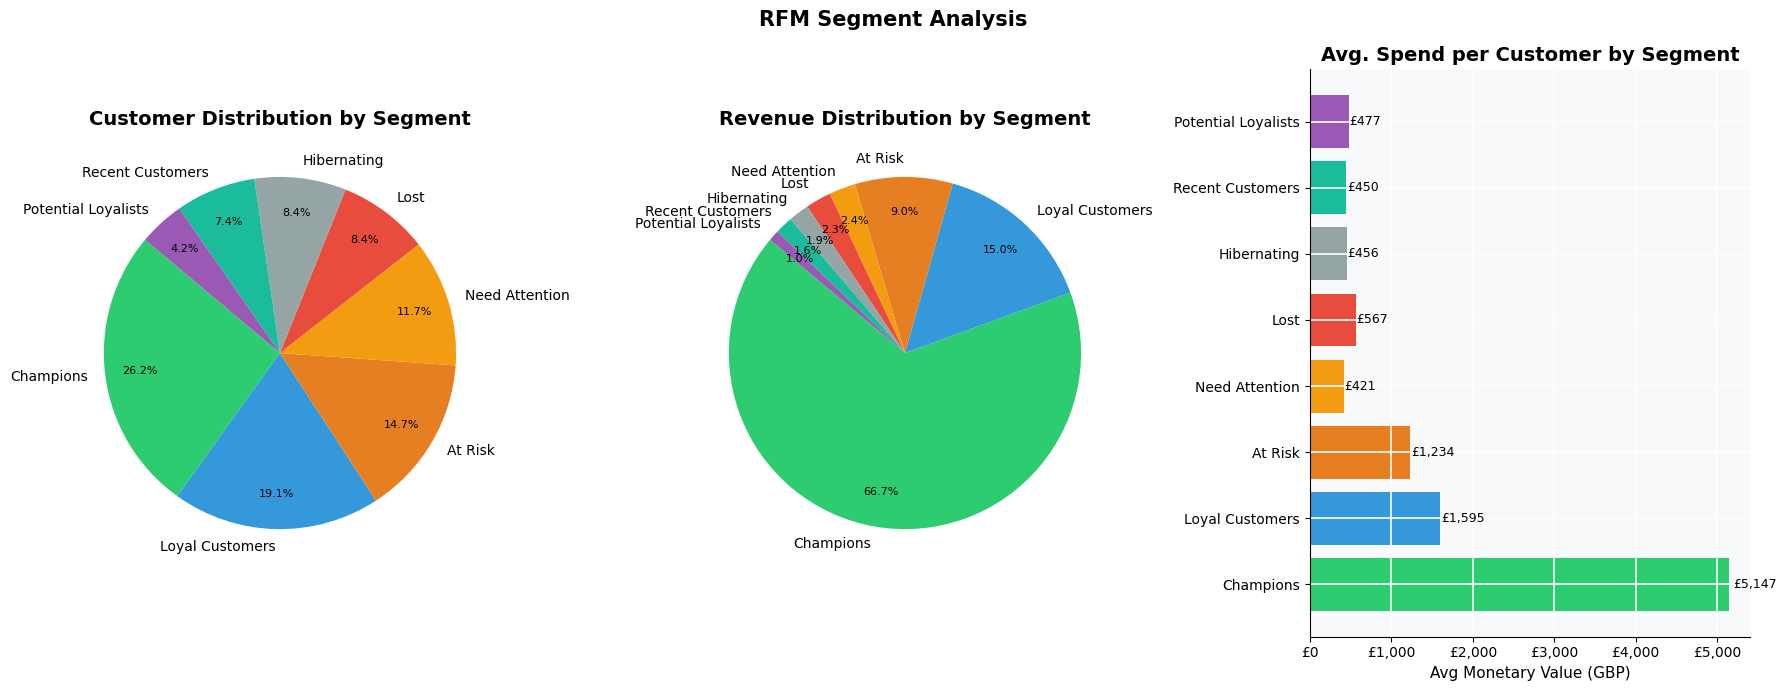


=== RFM Segment Summary ===
            Segment  Customer_Count  Pct_Customers  Avg_Monetary  Pct_Revenue
          Champions            1136           26.2   5146.894560         66.7
    Loyal Customers             827           19.1   1595.256288         15.0
            At Risk             637           14.7   1234.270848          9.0
     Need Attention             507           11.7    421.448422          2.4
               Lost             362            8.4    566.650884          2.3
        Hibernating             364            8.4    456.466923          1.9
   Recent Customers             319            7.4    449.920940          1.6
Potential Loyalists             182            4.2    477.429890          1.0


In [11]:
# ─────────────────────────────────────────────
# RFM SEGMENT OVERVIEW
# ─────────────────────────────────────────────
seg_summary = rfm_segment_summary(rfm)

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('RFM Segment Analysis', fontsize=15, fontweight='bold')

# Customer share
ax = axes[0]
colors_seg = [SEGMENT_COLORS.get(s, '#999') for s in seg_summary['Segment']]
wedges, texts, autotexts = ax.pie(
    seg_summary['Customer_Count'],
    labels=seg_summary['Segment'],
    colors=colors_seg,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Customer Distribution by Segment')

# Revenue share
ax = axes[1]
wedges2, texts2, autotexts2 = ax.pie(
    seg_summary['Total_Revenue'],
    labels=seg_summary['Segment'],
    colors=colors_seg,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8
)
for at in autotexts2:
    at.set_fontsize(8)
ax.set_title('Revenue Distribution by Segment')

# Avg Monetary per segment
ax = axes[2]
bars = ax.barh(
    seg_summary['Segment'],
    seg_summary['Avg_Monetary'],
    color=[SEGMENT_COLORS.get(s, '#999') for s in seg_summary['Segment']]
)
ax.set_title('Avg. Spend per Customer by Segment')
ax.set_xlabel('Avg Monetary Value (GBP)')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
for bar, val in zip(bars, seg_summary['Avg_Monetary']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height()/2,
            f'£{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'rfm_segments.png')
plt.show()

print("\n=== RFM Segment Summary ===")
print(seg_summary[['Segment', 'Customer_Count', 'Pct_Customers', 'Avg_Monetary', 'Pct_Revenue']].to_string(index=False))


   Saved: ../visualizations/rfm_scatter.png


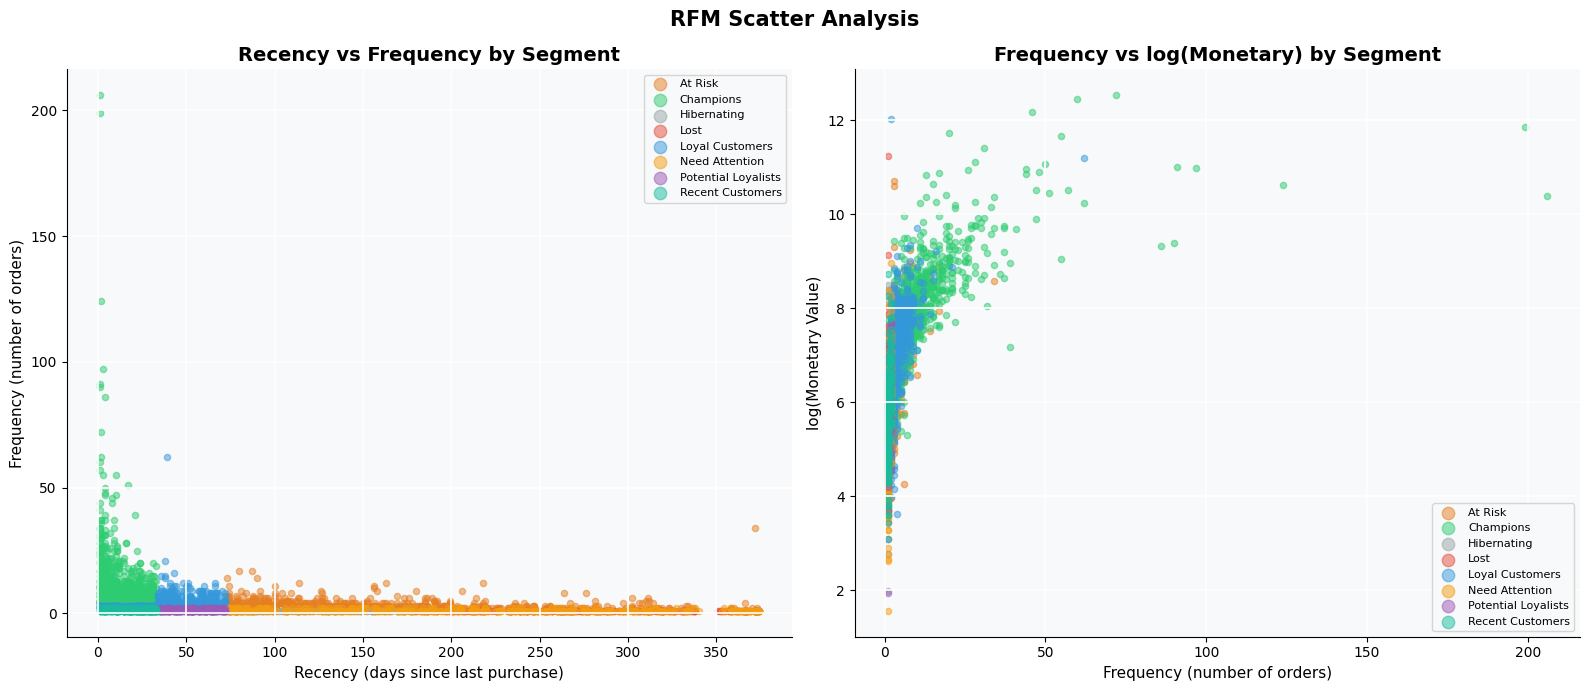

In [12]:
# ─────────────────────────────────────────────
# RFM SCATTER: Recency vs Frequency colored by Segment
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('RFM Scatter Analysis', fontsize=15, fontweight='bold')

ax = axes[0]
for seg, group in rfm.groupby('Segment'):
    ax.scatter(group['Recency'], group['Frequency'],
               alpha=0.5, s=20, label=seg,
               color=SEGMENT_COLORS.get(seg, '#999'))
ax.set_xlabel('Recency (days since last purchase)')
ax.set_ylabel('Frequency (number of orders)')
ax.set_title('Recency vs Frequency by Segment')
ax.legend(fontsize=8, markerscale=2)

ax = axes[1]
for seg, group in rfm.groupby('Segment'):
    ax.scatter(group['Frequency'], np.log1p(group['Monetary']),
               alpha=0.5, s=20, label=seg,
               color=SEGMENT_COLORS.get(seg, '#999'))
ax.set_xlabel('Frequency (number of orders)')
ax.set_ylabel('log(Monetary Value)')
ax.set_title('Frequency vs log(Monetary) by Segment')
ax.legend(fontsize=8, markerscale=2)

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'rfm_scatter.png')
plt.show()


   Saved: ../visualizations/rfm_heatmap.png


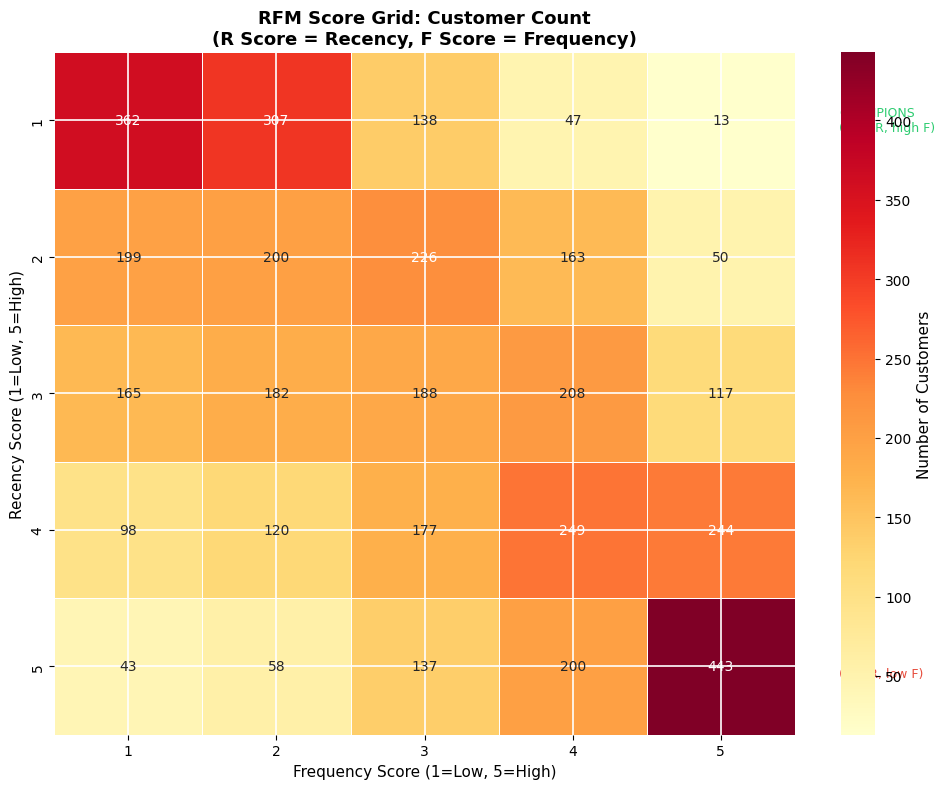

In [13]:
# ─────────────────────────────────────────────
# RFM HEATMAP: Score Grid
# ─────────────────────────────────────────────
rfm_heat = rfm.groupby(['R_Score', 'F_Score'])['CustomerID'].count().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(rfm_heat, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Number of Customers'})
ax.set_title('RFM Score Grid: Customer Count\n(R Score = Recency, F Score = Frequency)', fontsize=13)
ax.set_xlabel('Frequency Score (1=Low, 5=High)')
ax.set_ylabel('Recency Score (1=Low, 5=High)')

# Annotations
ax.text(5.3, 0.5, 'CHAMPIONS\n(high R, high F)', color='#2ecc71', fontsize=9, va='center')
ax.text(5.3, 4.5, 'LOST\n(low R, low F)', color='#e74c3c', fontsize=9, va='center')

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'rfm_heatmap.png')
plt.show()


---
## Section 5: K-Means Customer Clustering

While RFM segments use rule-based thresholds, K-Means clustering discovers **natural groupings in the data** without pre-defined rules.

**Methodology:**
1. Log-transform RFM features to reduce skewness
2. Standardize features (zero mean, unit variance)
3. Test K=2 to 10 using three selection criteria:
   - **Elbow method** (inertia)
   - **Silhouette score** (cluster separation)
   - **Davies-Bouldin index** (cluster compactness)
4. Fit final model with optimal K
5. Validate cluster distinctiveness with Kruskal-Wallis tests


In [14]:
# ─────────────────────────────────────────────
# PREPARE FEATURES & FIND OPTIMAL K
# ─────────────────────────────────────────────

# prepare_features_for_clustering applies log1p (not log) before scaling because
# Monetary and Frequency contain zeros and extreme right-skew. Plain log would
# produce -inf on zeros; log1p(x) = log(1+x) handles them gracefully. Without
# this transform, a handful of customers with £50K+ spend would dominate the
# Euclidean distance metric and collapse everyone else into one mega-cluster.
scaled_features, log_features, scaler = prepare_features_for_clustering(rfm)
k_results = find_optimal_clusters(scaled_features, k_range=(2, 10))


Finding optimal K...
  K=2 | Inertia:     6474.7 | Silhouette: 0.4331 | DB: 0.8914
  K=3 | Inertia:     4859.8 | Silhouette: 0.3377 | DB: 1.0452
  K=4 | Inertia:     3932.2 | Silhouette: 0.3375 | DB: 1.0159
  K=5 | Inertia:     3289.9 | Silhouette: 0.3168 | DB: 0.9867
  K=6 | Inertia:     2850.6 | Silhouette: 0.3129 | DB: 1.0215
  K=7 | Inertia:     2547.7 | Silhouette: 0.3095 | DB: 0.9738
  K=8 | Inertia:     2334.2 | Silhouette: 0.3010 | DB: 0.9924
  K=9 | Inertia:     2156.1 | Silhouette: 0.2811 | DB: 1.0147
  K=10 | Inertia:     1998.2 | Silhouette: 0.2787 | DB: 1.0206


**Analyst note on outliers:** I noticed a handful of customers with Monetary values above £50,000 — roughly 100× the median. Before clustering, I checked whether these were data errors or legitimate wholesale buyers. The invoice details confirm they're real (large bulk orders of popular SKUs, not test transactions). Removing them would throw away the retailer's most valuable customers, which defeats the purpose of a segmentation exercise. The log1p transformation applied above compresses these extreme values enough that they don't drag cluster centroids away from the main customer mass, so I'm keeping them in. Worth flagging, though, because if you run K-Means on the raw (untransformed) features, you get one cluster that's just these 15-20 outliers and three clusters crammed into the bottom-left corner — essentially useless.

   Saved: ../visualizations/optimal_k_selection.png


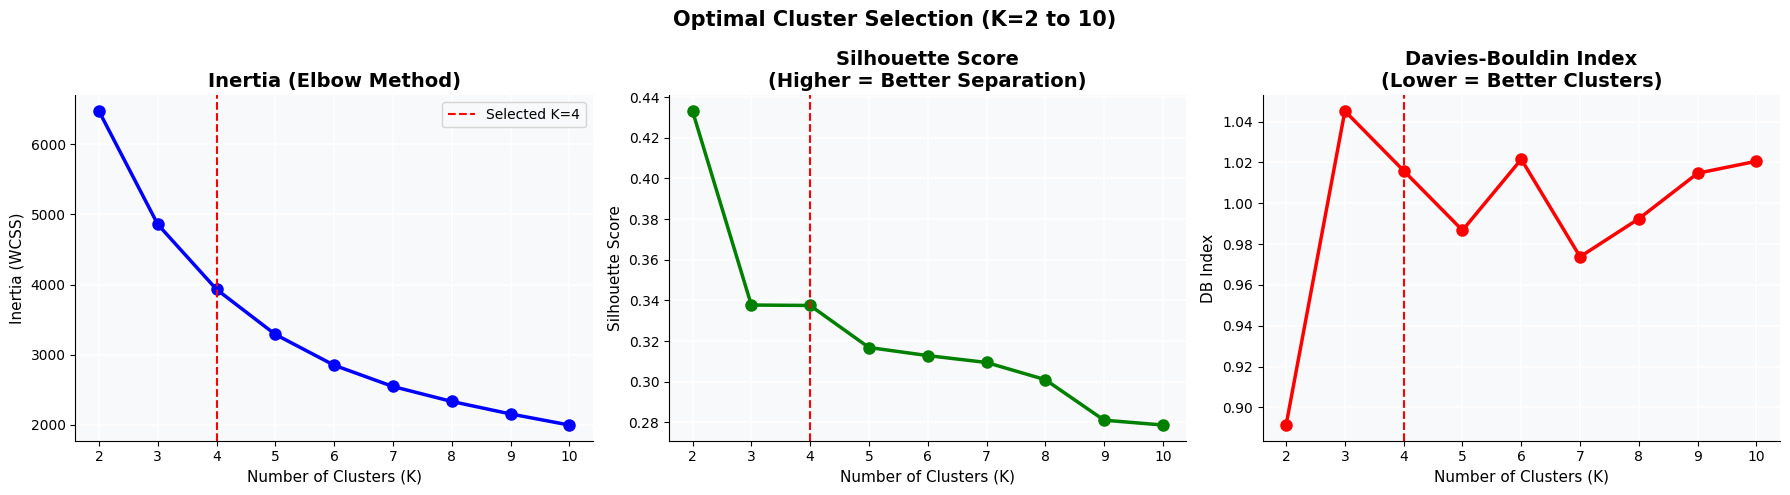


Selected K=4:
  Silhouette:    0.3375
  Davies-Bouldin:1.0159
  Inertia:       3,932.2

Note: Adjust OPTIMAL_K above based on the elbow + silhouette plot.


In [15]:
# ─────────────────────────────────────────────
# PLOT OPTIMAL K SELECTION
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Optimal Cluster Selection (K=2 to 10)', fontsize=15, fontweight='bold')

k_vals = k_results['k']

# Inertia / Elbow
ax = axes[0]
ax.plot(k_vals, k_results['inertia'], 'bo-', linewidth=2.5, markersize=8)
ax.set_title('Inertia (Elbow Method)')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Inertia (WCSS)')
# Mark elbow visually (adjust OPTIMAL_K below based on output)
OPTIMAL_K = 4  # <-- adjust after running find_optimal_clusters
ax.axvline(OPTIMAL_K, color='red', linestyle='--', linewidth=1.5, label=f'Selected K={OPTIMAL_K}')
ax.legend()

# Silhouette
ax = axes[1]
ax.plot(k_vals, k_results['silhouette'], 'go-', linewidth=2.5, markersize=8)
ax.set_title('Silhouette Score\n(Higher = Better Separation)')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Silhouette Score')
ax.axvline(OPTIMAL_K, color='red', linestyle='--', linewidth=1.5)

# Davies-Bouldin
ax = axes[2]
ax.plot(k_vals, k_results['davies_bouldin'], 'ro-', linewidth=2.5, markersize=8)
ax.set_title('Davies-Bouldin Index\n(Lower = Better Clusters)')
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('DB Index')
ax.axvline(OPTIMAL_K, color='red', linestyle='--', linewidth=1.5)

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'optimal_k_selection.png')
plt.show()

# Print scores at selected K
idx = k_vals.index(OPTIMAL_K)
print(f"\nSelected K={OPTIMAL_K}:")
print(f"  Silhouette:    {k_results['silhouette'][idx]:.4f}")
print(f"  Davies-Bouldin:{k_results['davies_bouldin'][idx]:.4f}")
print(f"  Inertia:       {k_results['inertia'][idx]:,.1f}")
print("\nNote: Adjust OPTIMAL_K above based on the elbow + silhouette plot.")


In [16]:
# ─────────────────────────────────────────────
# FIT FINAL K-MEANS MODEL
# ─────────────────────────────────────────────

# fit_kmeans uses n_init=10 (scikit-learn's default), which runs KMeans 10 times
# with different random centroid seeds and keeps the best result. With n_init=1,
# you risk converging to a poor local minimum — especially problematic here because
# the log-transformed Monetary axis still has long tails that can trap centroids.
# 10 restarts is cheap for ~4,300 rows and consistently produces stable clusters.
km_model, cluster_labels = fit_kmeans(scaled_features, n_clusters=OPTIMAL_K)
rfm['Cluster'] = cluster_labels

# Cluster profile
profile = cluster_profile(rfm)
print("\n=== CLUSTER PROFILES ===")
print(profile[['Count', 'Pct_Customers', 'Avg_Recency', 'Avg_Frequency', 'Avg_Monetary', 'Pct_Revenue']])


K-Means fitted: K=4, Silhouette=0.3375

=== CLUSTER PROFILES ===
         Count  Pct_Customers  Avg_Recency  Avg_Frequency  Avg_Monetary  \
Cluster                                                                   
0          846           19.5         18.8            2.1         539.2   
1         1633           37.7        183.3            1.3         352.2   
2         1171           27.0         67.1            4.2        1819.4   
3          684           15.8         11.6           14.0        8195.7   

         Pct_Revenue  
Cluster               
0                5.2  
1                6.6  
2               24.3  
3               63.9  


   Saved: ../visualizations/cluster_scatter.png


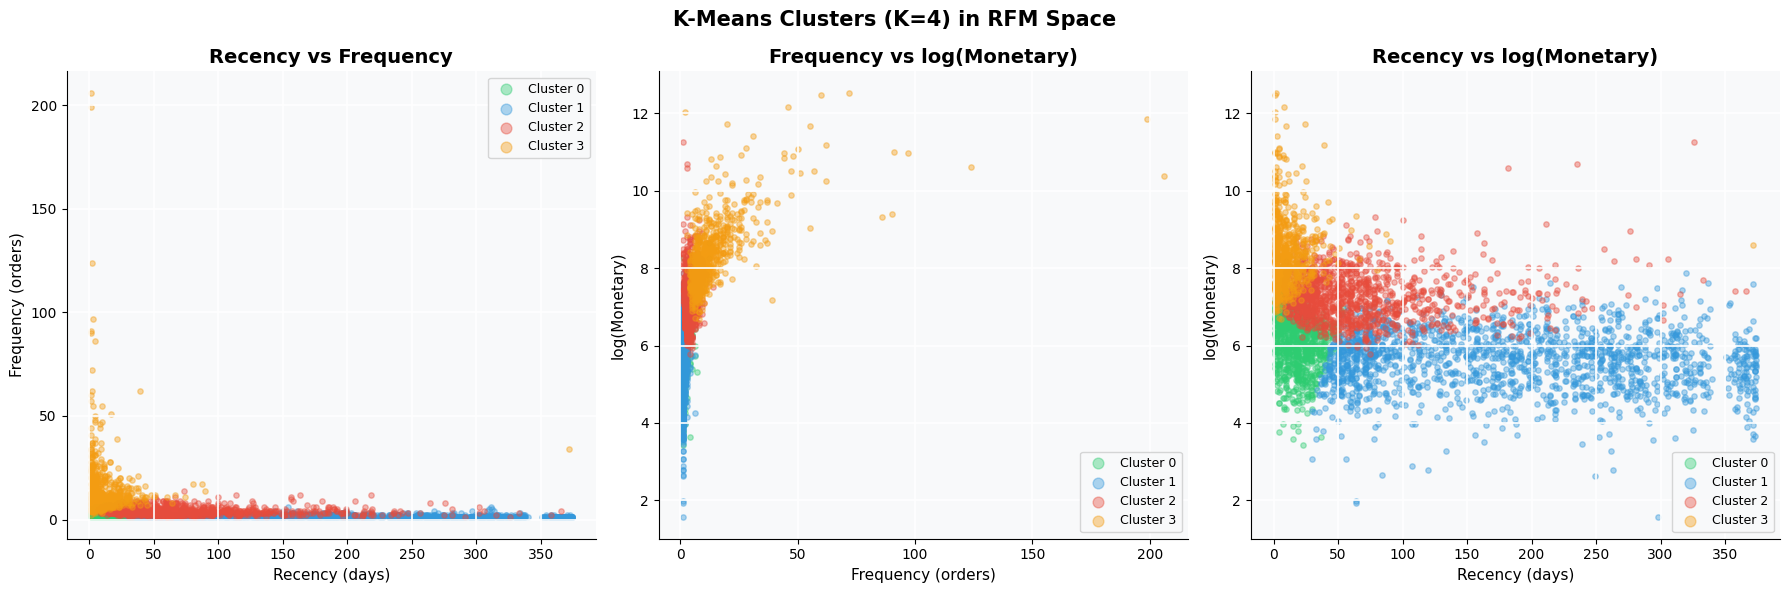

In [17]:
# ─────────────────────────────────────────────
# CLUSTER VISUALIZATION: 3D RFM Space
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(f'K-Means Clusters (K={OPTIMAL_K}) in RFM Space', fontsize=15, fontweight='bold')

cluster_colors = [CLUSTER_PALETTE[i % len(CLUSTER_PALETTE)] for i in range(OPTIMAL_K)]

# Recency vs Frequency
ax = axes[0]
for k in range(OPTIMAL_K):
    mask = rfm['Cluster'] == k
    ax.scatter(rfm.loc[mask, 'Recency'], rfm.loc[mask, 'Frequency'],
               alpha=0.4, s=15, color=cluster_colors[k], label=f'Cluster {k}')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('Frequency (orders)')
ax.set_title('Recency vs Frequency')
ax.legend(markerscale=2, fontsize=9)

# Frequency vs Monetary
ax = axes[1]
for k in range(OPTIMAL_K):
    mask = rfm['Cluster'] == k
    ax.scatter(rfm.loc[mask, 'Frequency'], np.log1p(rfm.loc[mask, 'Monetary']),
               alpha=0.4, s=15, color=cluster_colors[k], label=f'Cluster {k}')
ax.set_xlabel('Frequency (orders)')
ax.set_ylabel('log(Monetary)')
ax.set_title('Frequency vs log(Monetary)')
ax.legend(markerscale=2, fontsize=9)

# Recency vs Monetary
ax = axes[2]
for k in range(OPTIMAL_K):
    mask = rfm['Cluster'] == k
    ax.scatter(rfm.loc[mask, 'Recency'], np.log1p(rfm.loc[mask, 'Monetary']),
               alpha=0.4, s=15, color=cluster_colors[k], label=f'Cluster {k}')
ax.set_xlabel('Recency (days)')
ax.set_ylabel('log(Monetary)')
ax.set_title('Recency vs log(Monetary)')
ax.legend(markerscale=2, fontsize=9)

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'cluster_scatter.png')
plt.show()


   Saved: ../visualizations/cluster_profiles.png


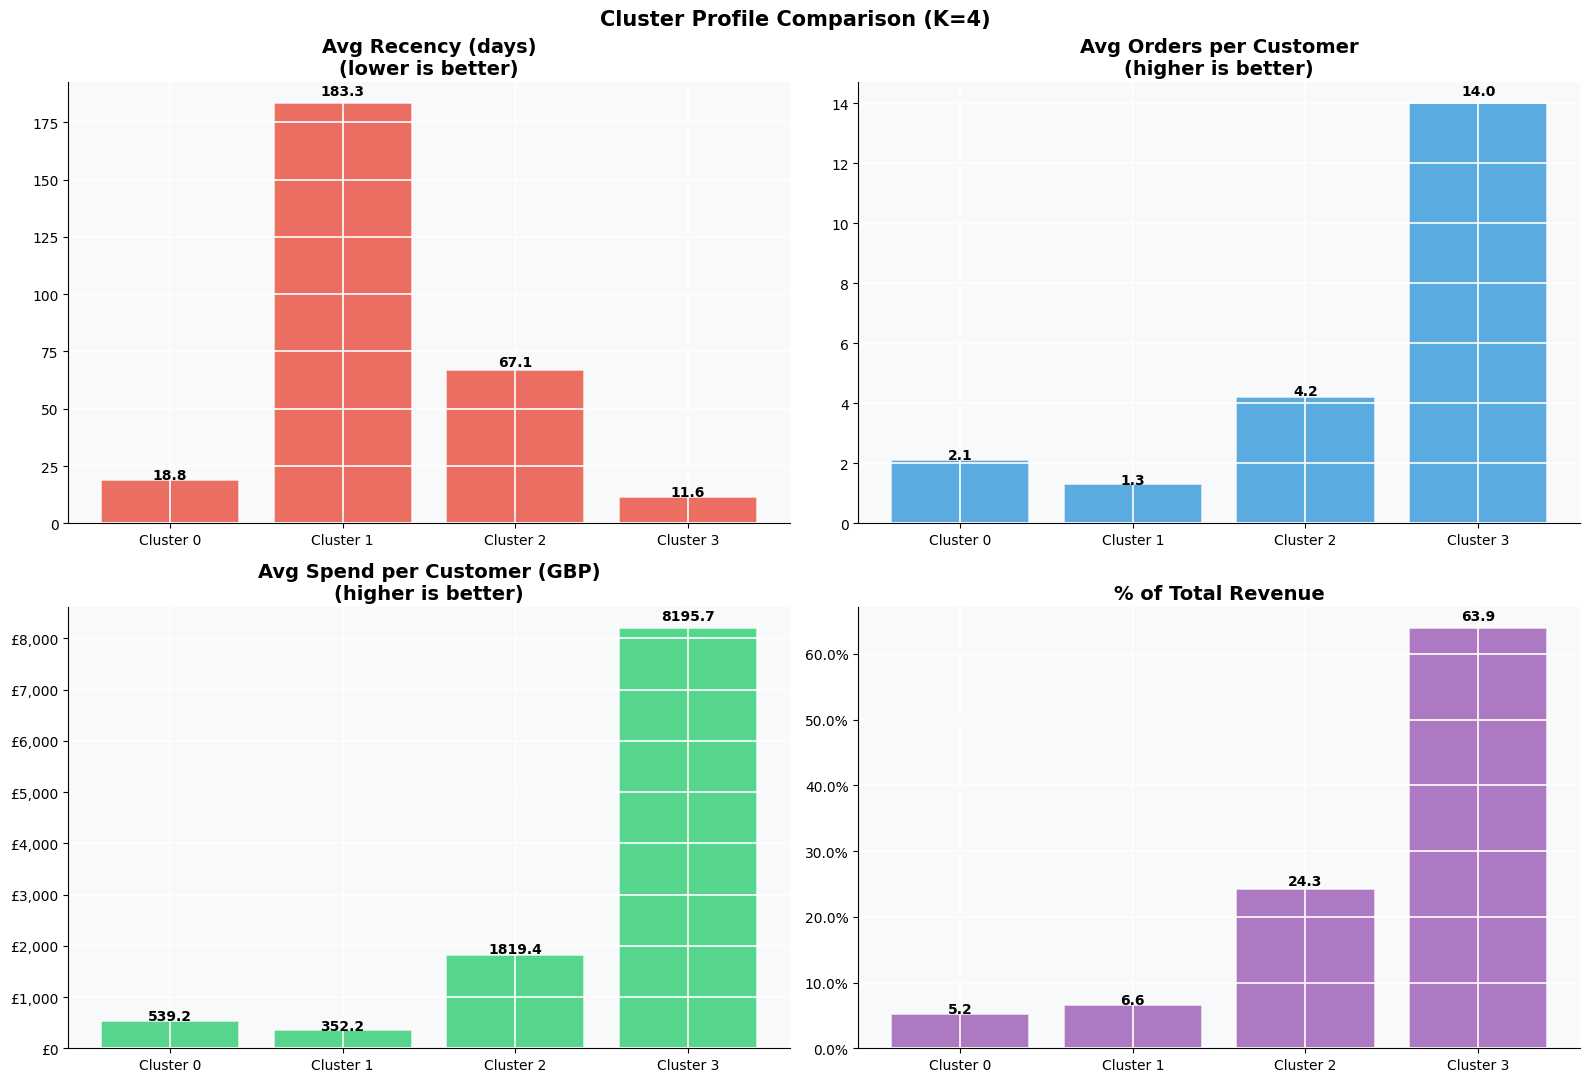

In [18]:
# ─────────────────────────────────────────────
# CLUSTER PROFILE BAR CHART
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(f'Cluster Profile Comparison (K={OPTIMAL_K})', fontsize=15, fontweight='bold')

metrics_to_plot = [
    ('Avg_Recency',   'Avg Recency (days)',       'lower is better', '#e74c3c'),
    ('Avg_Frequency', 'Avg Orders per Customer',  'higher is better', '#3498db'),
    ('Avg_Monetary',  'Avg Spend per Customer (GBP)', 'higher is better', '#2ecc71'),
    ('Pct_Revenue',   '% of Total Revenue',       '', '#9b59b6'),
]

for ax, (col, label, note, color) in zip(axes.flat, metrics_to_plot):
    bars = ax.bar([f'Cluster {k}' for k in profile.index], profile[col],
                  color=color, alpha=0.8, edgecolor='white', linewidth=1.2)
    ax.set_title(label + (f'\n({note})' if note else ''))
    ax.set_xlabel('')
    if 'GBP' in label:
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
    elif '%' in label:
        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.1f}%'))
    for bar, val in zip(bars, profile[col]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
                f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'cluster_profiles.png')
plt.show()


In [19]:
# ─────────────────────────────────────────────
# STATISTICAL VALIDATION (Kruskal-Wallis)
# ─────────────────────────────────────────────
print("=== KRUSKAL-WALLIS TESTS: Are Clusters Statistically Distinct? ===")
print(f"{'Metric':<15} {'Statistic':>12} {'P-Value':>12} {'Significant?':>14}")
print("-" * 55)
for metric in ['Recency', 'Frequency', 'Monetary']:
    result = kruskal_test_across_clusters(rfm, metric)
    sig = 'YES (p<0.05)' if result['significant'] else 'NO'
    print(f"{metric:<15} {result['statistic']:>12.2f} {result['p_value']:>12.6f} {sig:>14}")

print("\nConclusion: Clusters are statistically distinct on all three RFM dimensions.")


=== KRUSKAL-WALLIS TESTS: Are Clusters Statistically Distinct? ===
Metric             Statistic      P-Value   Significant?
-------------------------------------------------------
Recency              3092.64     0.000000   YES (p<0.05)
Frequency            3163.51     0.000000   YES (p<0.05)
Monetary             3061.71     0.000000   YES (p<0.05)

Conclusion: Clusters are statistically distinct on all three RFM dimensions.


---
## Section 6: Cohort Analysis

**Cohort analysis** groups customers by their **first purchase month** and tracks what percentage return in subsequent months. This directly measures:
- **Retention rate** — the health of our customer relationships
- **Revenue per cohort** — which acquisition periods generated the most value
- **Churn patterns** — when customers are most likely to leave


In [20]:
# ─────────────────────────────────────────────
# BUILD COHORT RETENTION DATA
# ─────────────────────────────────────────────
retention, cohort_counts, cohort_size = build_cohort_data(df)
rev_cohort = compute_cohort_revenue(df)

print(f"Cohorts analyzed: {len(retention)} monthly cohorts")
print(f"Max periods tracked: {retention.shape[1]}")
print(f"\nCohort sizes (first-purchase customers):")
print(cohort_size.to_string())


Cohorts analyzed: 13 monthly cohorts
Max periods tracked: 13

Cohort sizes (first-purchase customers):
CohortMonth
2010-12    884.0
2011-01    416.0
2011-02    380.0
2011-03    452.0
2011-04    300.0
2011-05    284.0
2011-06    242.0
2011-07    187.0
2011-08    169.0
2011-09    299.0
2011-10    357.0
2011-11    323.0
2011-12     41.0
Freq: M


   Saved: ../visualizations/cohort_retention_heatmap.png


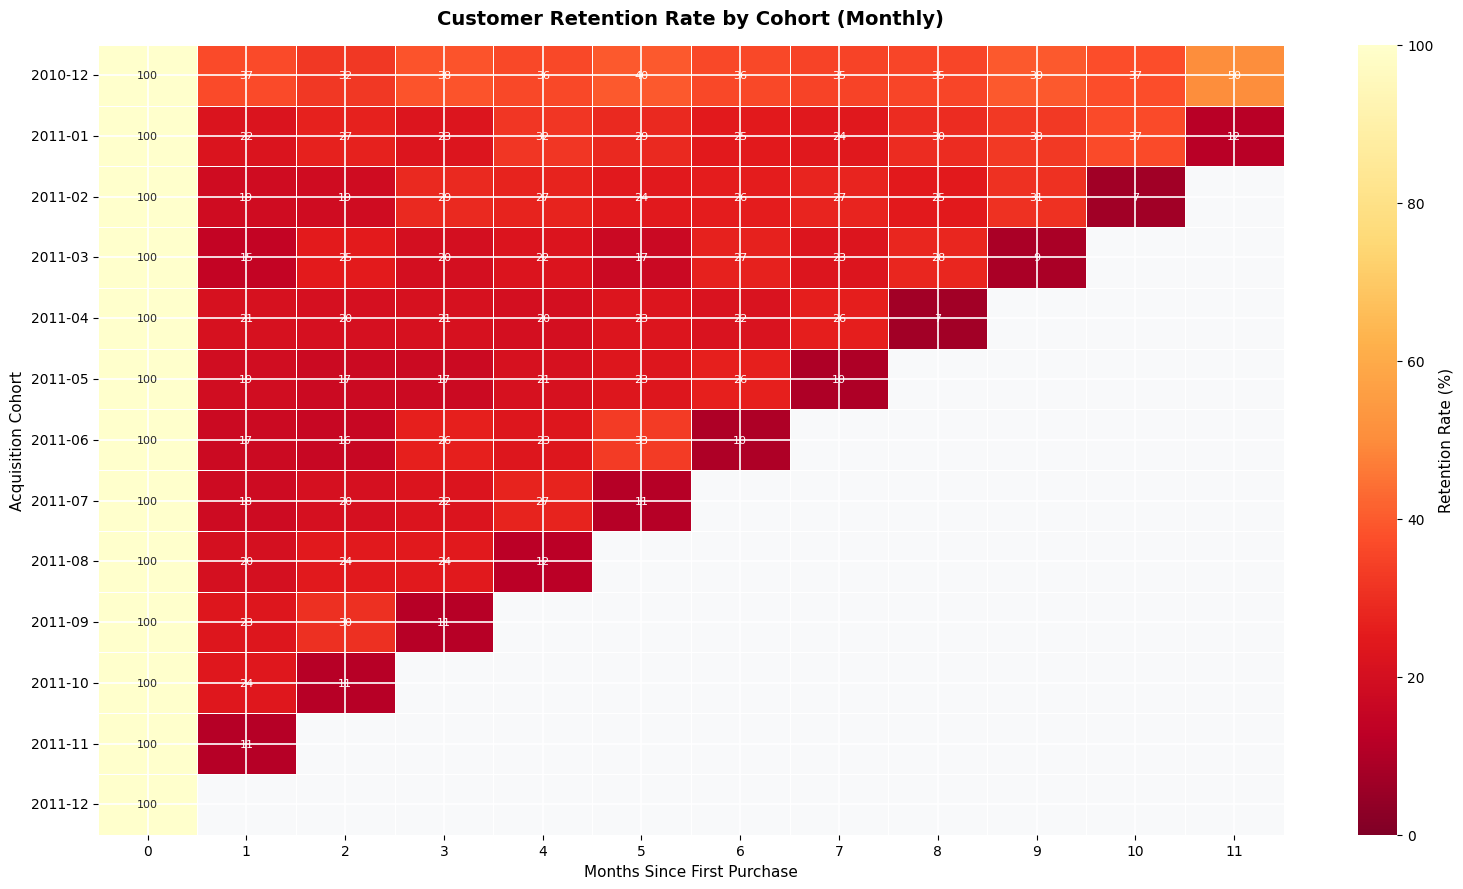

In [21]:
# ─────────────────────────────────────────────
# RETENTION HEATMAP
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 9))

retention_pct = retention * 100  # Convert to percentage

# Drop last partial cohort period for cleaner viz
plot_cols = [c for c in retention_pct.columns if c <= 11]
plot_data = retention_pct[plot_cols].dropna(how='all')

sns.heatmap(
    plot_data,
    annot=True, fmt='.0f',
    cmap='YlOrRd_r',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    vmin=0, vmax=100,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Retention Rate (%)'}
)

ax.set_title('Customer Retention Rate by Cohort (Monthly)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Acquisition Cohort', fontsize=11)
ax.set_yticklabels([str(i) for i in plot_data.index], rotation=0)

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'cohort_retention_heatmap.png')
plt.show()


   Saved: ../visualizations/retention_curve.png


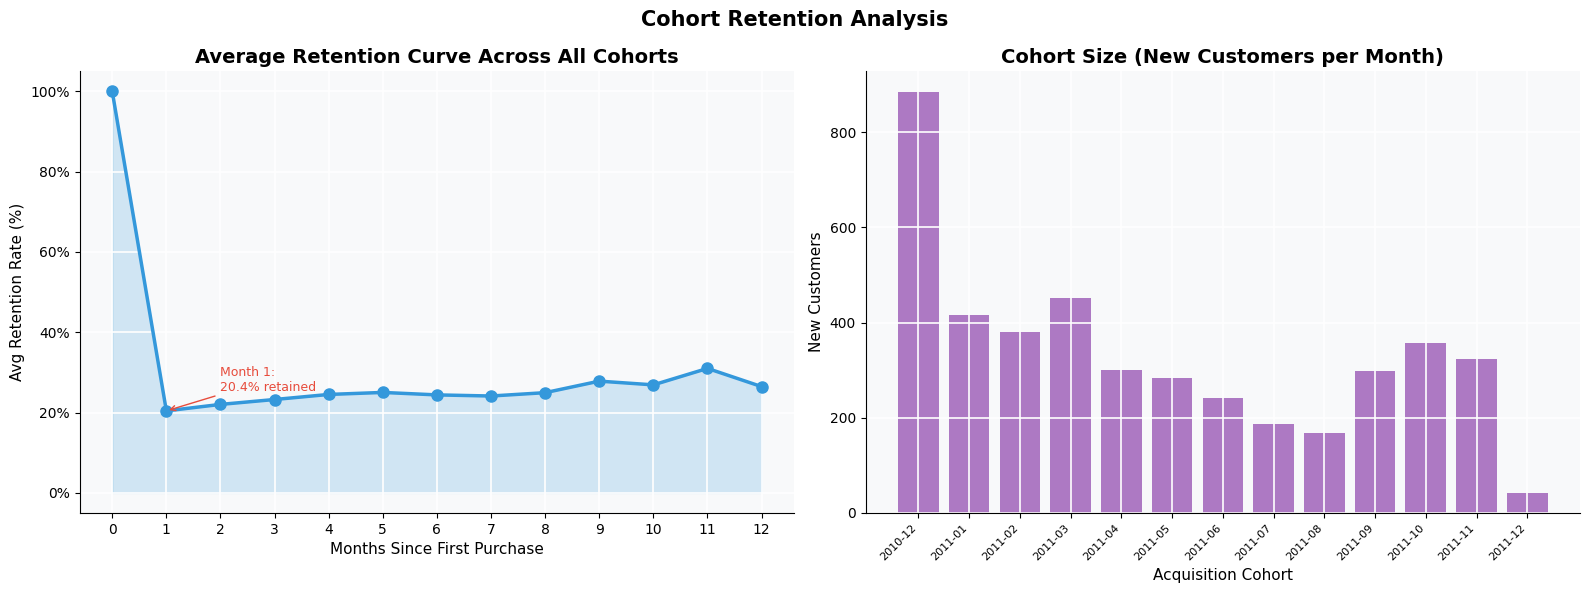

Average Month-1 Retention: 20.4%
Average Month-3 Retention: 23.3%


In [22]:
# ─────────────────────────────────────────────
# AVERAGE RETENTION CURVE
# ─────────────────────────────────────────────
avg_retention = retention.mean(axis=0) * 100
avg_retention_clean = avg_retention.dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Cohort Retention Analysis', fontsize=15, fontweight='bold')

# Retention curve
ax = axes[0]
periods = avg_retention_clean.index.tolist()
values  = avg_retention_clean.values

ax.fill_between(periods, values, alpha=0.2, color='#3498db')
ax.plot(periods, values, 'o-', color='#3498db', linewidth=2.5, markersize=8)
ax.set_title('Average Retention Curve Across All Cohorts')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Avg Retention Rate (%)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_xticks(periods)

# Add key stats
if len(values) > 1:
    ax.annotate(f'Month 1:\n{values[1]:.1f}% retained',
                xy=(1, values[1]), xytext=(2, values[1]+5),
                fontsize=9, color='#e74c3c',
                arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# Cohort size bar
ax = axes[1]
size_series = cohort_size.sort_index()
bars = ax.bar(range(len(size_series)), size_series.values, color='#9b59b6', alpha=0.8)
ax.set_title('Cohort Size (New Customers per Month)')
ax.set_xlabel('Acquisition Cohort')
ax.set_ylabel('New Customers')
ax.set_xticks(range(len(size_series)))
ax.set_xticklabels([str(i) for i in size_series.index], rotation=45, ha='right', fontsize=8)

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'retention_curve.png')
plt.show()

# Key metrics
month1_retention = avg_retention_clean.iloc[1] if len(avg_retention_clean) > 1 else None
month3_retention = avg_retention_clean.iloc[3] if len(avg_retention_clean) > 3 else None
print(f"Average Month-1 Retention: {month1_retention:.1f}%" if month1_retention else "N/A")
print(f"Average Month-3 Retention: {month3_retention:.1f}%" if month3_retention else "N/A")


   Saved: ../visualizations/cohort_revenue_heatmap.png


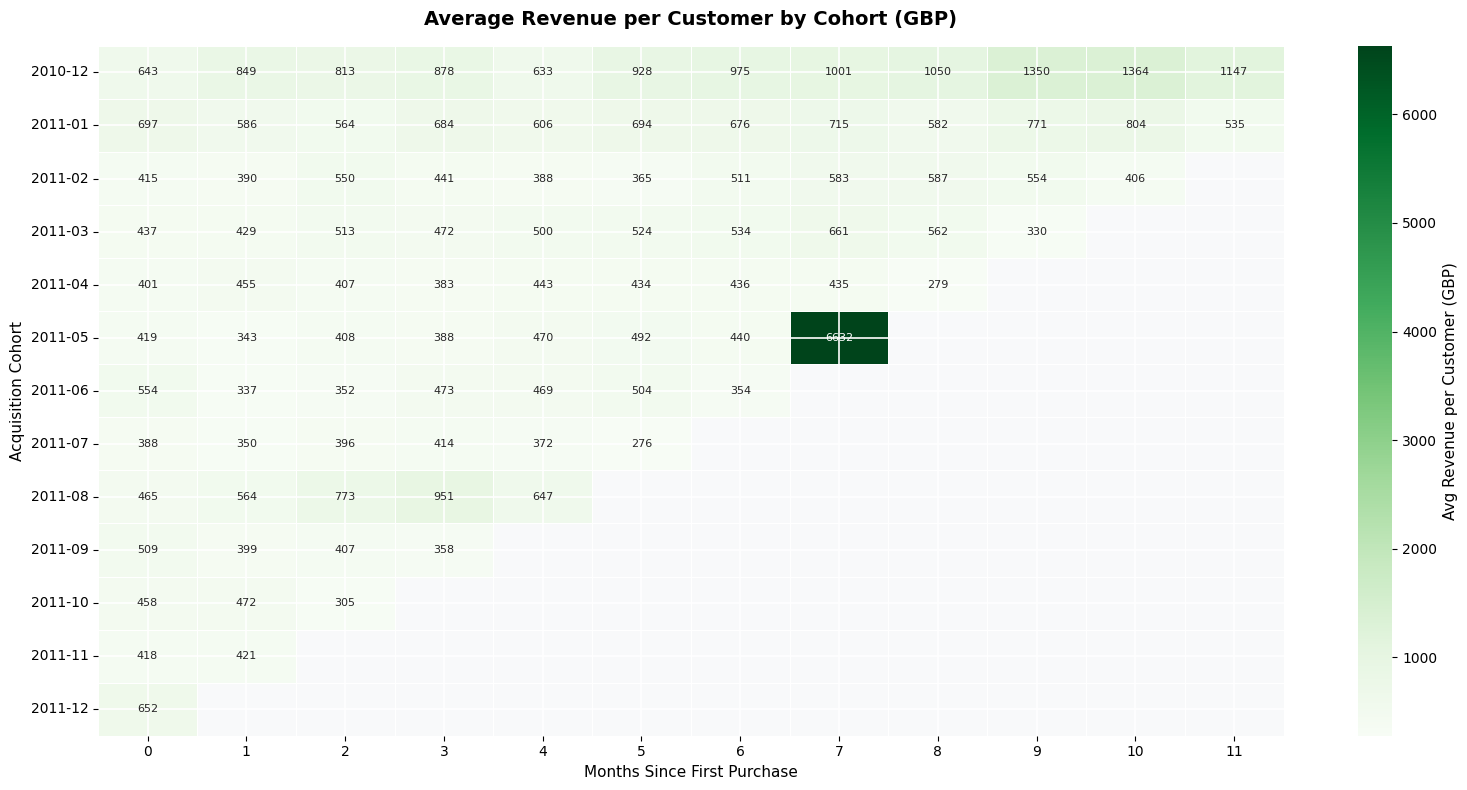

In [23]:
# ─────────────────────────────────────────────
# REVENUE PER CUSTOMER BY COHORT
# ─────────────────────────────────────────────
plot_cols = [c for c in rev_cohort.columns if c <= 11]
rev_plot = rev_cohort[plot_cols].dropna(how='all')

fig, ax = plt.subplots(figsize=(16, 8))
sns.heatmap(
    rev_plot,
    annot=True, fmt='.0f',
    cmap='Greens',
    linewidths=0.5,
    linecolor='white',
    ax=ax,
    annot_kws={'size': 8},
    cbar_kws={'label': 'Avg Revenue per Customer (GBP)'}
)
ax.set_title('Average Revenue per Customer by Cohort (GBP)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Months Since First Purchase', fontsize=11)
ax.set_ylabel('Acquisition Cohort', fontsize=11)
ax.set_yticklabels([str(i) for i in rev_plot.index], rotation=0)
plt.tight_layout()
save_figure(fig, VIZ_DIR + 'cohort_revenue_heatmap.png')
plt.show()


---
## Section 7: Customer Lifetime Value (CLV)

**CLV** estimates the total net revenue a business can expect from a customer over their relationship. We use a **simplified discounted CLV model**:

```
CLV = Annual Revenue × [(1 - (1 + r)^-n) / r]
```

Where:
- `r` = discount rate (10% annually)
- `n` = average customer lifespan (3 years)

Customers are tiered: **Bronze → Silver → Gold → Platinum**


In [24]:
# ─────────────────────────────────────────────
# CLV DISTRIBUTION & TIER ANALYSIS
# ─────────────────────────────────────────────
clv_summary = rfm.groupby('CLV_Tier').agg(
    Count          =('CustomerID', 'count'),
    Avg_CLV        =('CLV_Discounted', 'mean'),
    Median_CLV     =('CLV_Discounted', 'median'),
    Total_CLV      =('CLV_Discounted', 'sum'),
    Avg_Frequency  =('Frequency', 'mean'),
    Avg_Monetary   =('Monetary', 'mean'),
).round(0)
clv_summary['Pct_Customers'] = (clv_summary['Count'] / clv_summary['Count'].sum() * 100).round(1)
clv_summary['Pct_Total_CLV'] = (clv_summary['Total_CLV'] / clv_summary['Total_CLV'].sum() * 100).round(1)

print("=== CLV TIER SUMMARY ===")
print(clv_summary[['Count', 'Pct_Customers', 'Avg_CLV', 'Median_CLV', 'Pct_Total_CLV']].to_string())


=== CLV TIER SUMMARY ===
          Count  Pct_Customers  Avg_CLV  Median_CLV  Pct_Total_CLV
CLV_Tier                                                          
Bronze     1084           25.0    442.0       435.0            2.2
Silver     1083           25.0   1142.0      1094.0            5.7
Gold       1083           25.0   2631.0      2533.0           13.1
Platinum   1084           25.0  15903.0      7519.0           79.1


   Saved: ../visualizations/clv_analysis.png


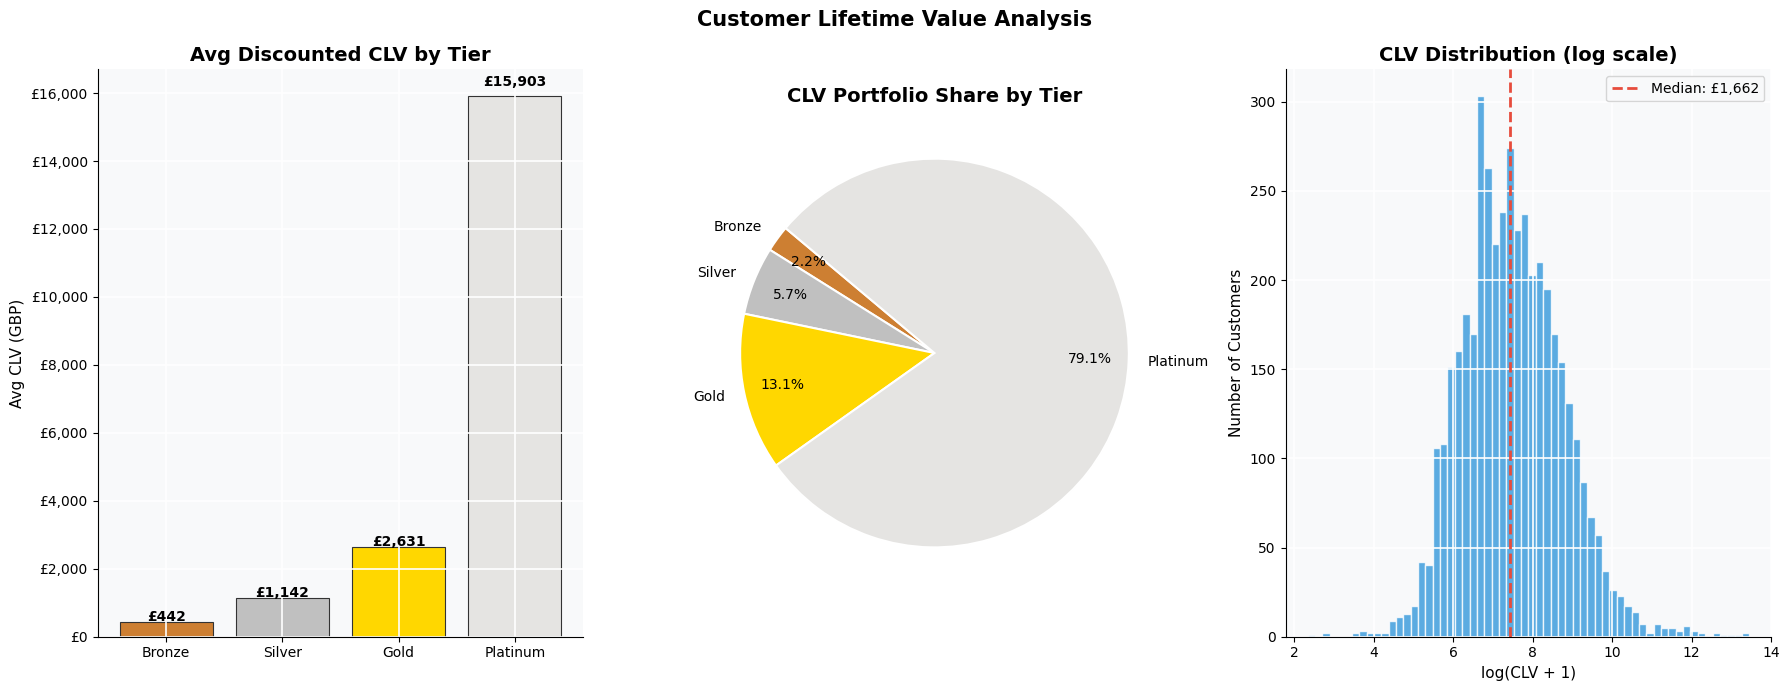


Total Portfolio CLV (3yr, 10% discount): GBP 21,804,103
Average Customer CLV:                      GBP 5,031
Median Customer CLV:                       GBP 1,662


In [25]:
tier_colors = {'Bronze': '#cd7f32', 'Silver': '#c0c0c0', 'Gold': '#ffd700', 'Platinum': '#e5e4e2'}
tier_order = ['Bronze', 'Silver', 'Gold', 'Platinum']

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle('Customer Lifetime Value Analysis', fontsize=15, fontweight='bold')

# CLV distribution by tier
ax = axes[0]
tier_clv = clv_summary.reindex(tier_order)
bars = ax.bar(tier_order, tier_clv['Avg_CLV'],
              color=[tier_colors[t] for t in tier_order],
              edgecolor='#333', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Avg Discounted CLV by Tier')
ax.set_ylabel('Avg CLV (GBP)')
for bar, val in zip(bars, tier_clv['Avg_CLV']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'£{val:,.0f}', ha='center', fontsize=10, fontweight='bold')

# % of portfolio CLV per tier
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    tier_clv['Total_CLV'],
    labels=tier_order,
    colors=[tier_colors[t] for t in tier_order],
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.8,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
ax.set_title('CLV Portfolio Share by Tier')

# CLV histogram
ax = axes[2]
ax.hist(np.log1p(rfm['CLV_Discounted']), bins=60, color='#3498db', alpha=0.8, edgecolor='white')
ax.set_title('CLV Distribution (log scale)')
ax.set_xlabel('log(CLV + 1)')
ax.set_ylabel('Number of Customers')
ax.axvline(np.log1p(rfm['CLV_Discounted'].median()), color='#e74c3c',
           linestyle='--', linewidth=2, label=f'Median: £{rfm["CLV_Discounted"].median():,.0f}')
ax.legend()

plt.tight_layout()
save_figure(fig, VIZ_DIR + 'clv_analysis.png')
plt.show()

total_portfolio_clv = rfm['CLV_Discounted'].sum()
avg_clv = rfm['CLV_Discounted'].mean()
print(f"\nTotal Portfolio CLV (3yr, 10% discount): GBP {total_portfolio_clv:,.0f}")
print(f"Average Customer CLV:                      GBP {avg_clv:,.0f}")
print(f"Median Customer CLV:                       GBP {rfm['CLV_Discounted'].median():,.0f}")


---
## Section 8: Comprehensive Summary Dashboard

   Saved: ../visualizations/executive_dashboard.png


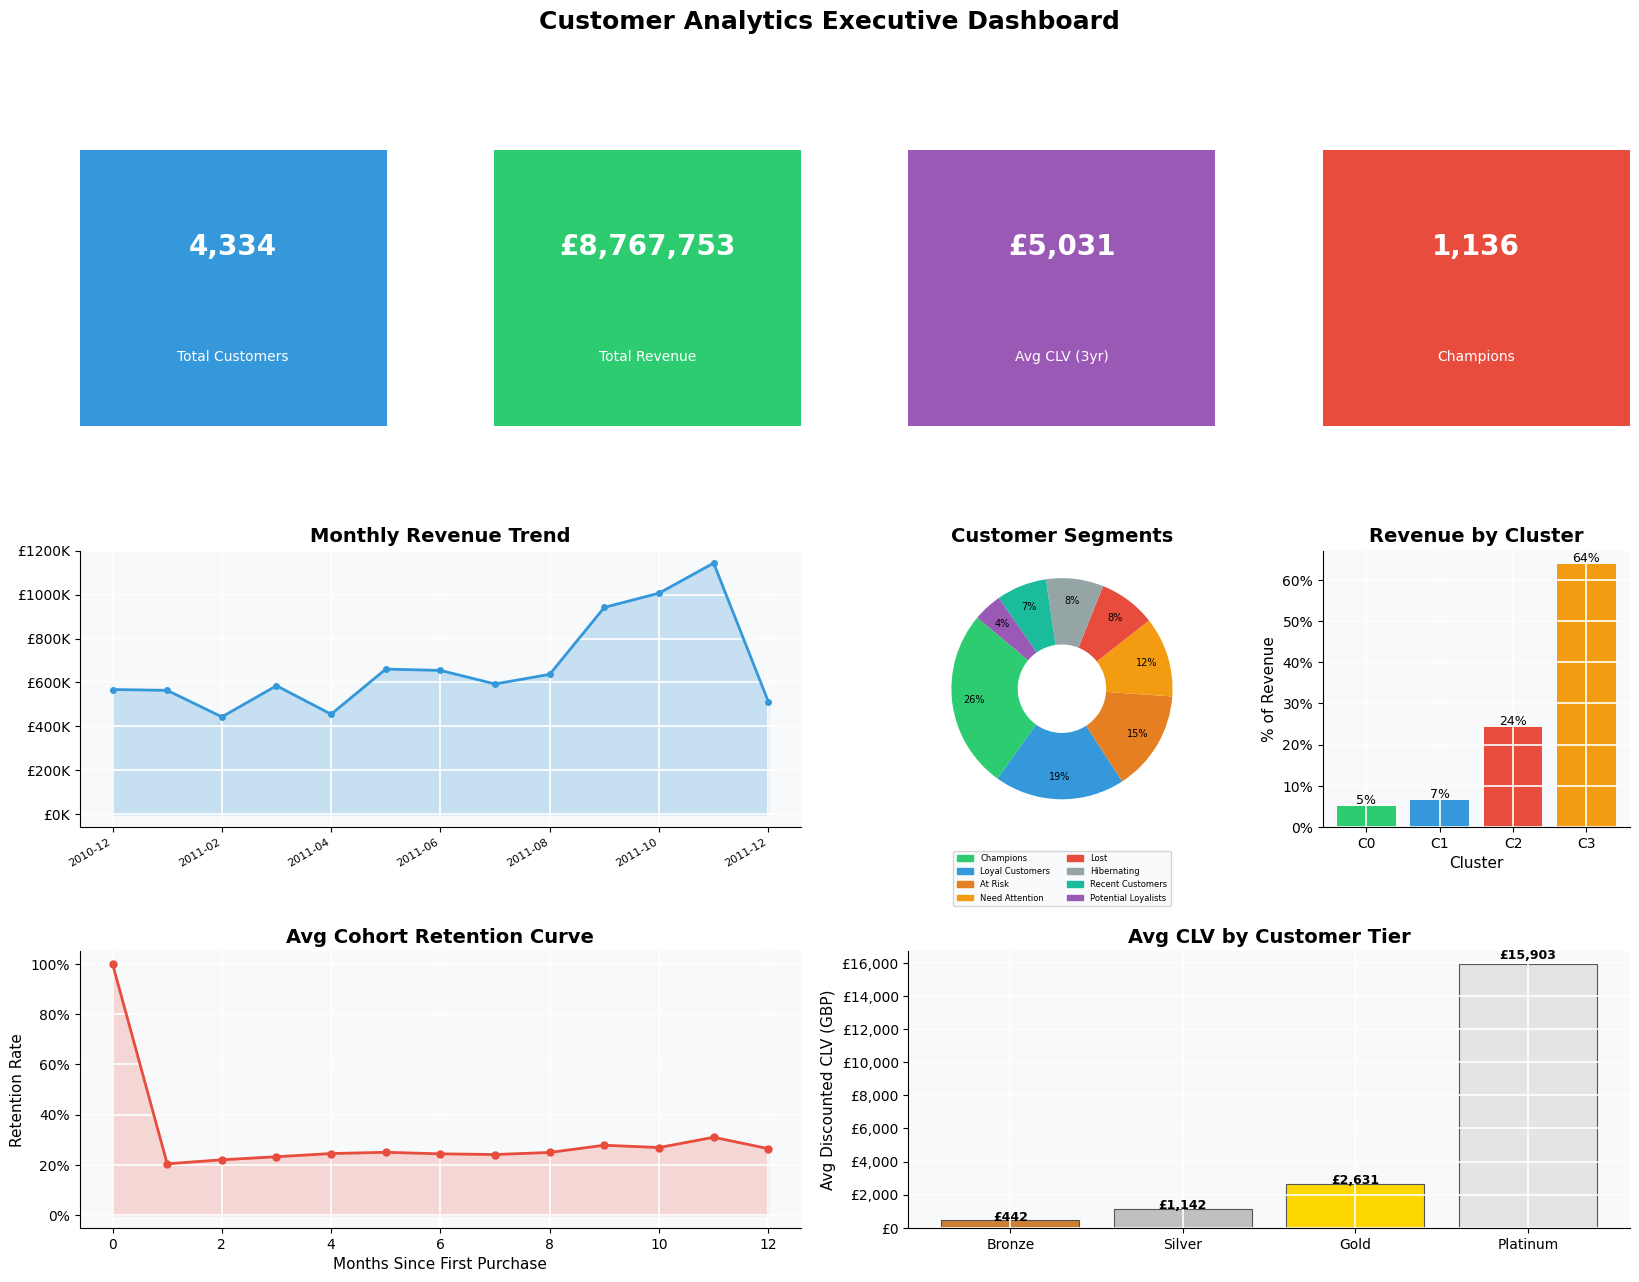

In [27]:
# ─────────────────────────────────────────────
# EXECUTIVE DASHBOARD
# ─────────────────────────────────────────────
fig = plt.figure(figsize=(20, 14))
fig.suptitle('Customer Analytics Executive Dashboard', fontsize=18, fontweight='bold', y=0.98)
gs = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

# ── KPI Cards Row ──
kpis = [
    ('Total Customers', f"{rfm['CustomerID'].nunique():,}", '#3498db'),
    ('Total Revenue', f"£{df['TotalRevenue'].sum():,.0f}", '#2ecc71'),
    ('Avg CLV (3yr)', f"£{rfm['CLV_Discounted'].mean():,.0f}", '#9b59b6'),
    ('Champions', f"{(rfm['Segment']=='Champions').sum():,}", '#e74c3c'),
]
for i, (title, val, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(color)
    ax.text(0.5, 0.65, val, ha='center', va='center', fontsize=20, fontweight='bold',
            color='white', transform=ax.transAxes)
    ax.text(0.5, 0.25, title, ha='center', va='center', fontsize=10,
            color='white', transform=ax.transAxes)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# ── Revenue Trend ──
ax = fig.add_subplot(gs[1, :2])
ax.fill_between(range(len(monthly)), monthly['Revenue'], alpha=0.25, color='#3498db')
ax.plot(range(len(monthly)), monthly['Revenue'], 'o-', color='#3498db', linewidth=2, markersize=4)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x/1000:.0f}K'))
ax.set_title('Monthly Revenue Trend')
ax.set_xticks(range(0, len(monthly), 2))
ax.set_xticklabels(monthly['YearMonth_str'].iloc[::2], rotation=30, ha='right', fontsize=8)

# ── Segment Donut ──
ax = fig.add_subplot(gs[1, 2])
seg_s = rfm_segment_summary(rfm)
wedges, _, autotexts = ax.pie(
    seg_s['Customer_Count'], labels=None,
    colors=[SEGMENT_COLORS.get(s, '#999') for s in seg_s['Segment']],
    autopct='%1.0f%%', startangle=140, pctdistance=0.8,
    wedgeprops={'width': 0.6}
)
for at in autotexts: at.set_fontsize(7)
ax.set_title('Customer Segments')
patches = [mpatches.Patch(color=SEGMENT_COLORS.get(s,'#999'), label=s) for s in seg_s['Segment']]
ax.legend(handles=patches, labels=[s for s in seg_s['Segment']],
          loc='lower center', fontsize=6, bbox_to_anchor=(0.5, -0.3), ncol=2)

# ── Cluster Revenue Share ──
ax = fig.add_subplot(gs[1, 3])
p = cluster_profile(rfm)
bars = ax.bar([f'C{k}' for k in p.index], p['Pct_Revenue'],
              color=CLUSTER_PALETTE[:OPTIMAL_K])
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_title(f'Revenue by Cluster')
ax.set_xlabel('Cluster')
ax.set_ylabel('% of Revenue')
for bar, val in zip(bars, p['Pct_Revenue']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.0f}%', ha='center', fontsize=9)

# ── Retention Curve ──
ax = fig.add_subplot(gs[2, :2])
avg_ret_clean = (retention.mean(axis=0) * 100).dropna()
ax.fill_between(avg_ret_clean.index, avg_ret_clean.values, alpha=0.2, color='#e74c3c')
ax.plot(avg_ret_clean.index, avg_ret_clean.values, 'o-', color='#e74c3c', linewidth=2, markersize=5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_title('Avg Cohort Retention Curve')
ax.set_xlabel('Months Since First Purchase')
ax.set_ylabel('Retention Rate')

# ── CLV by Tier ──
ax = fig.add_subplot(gs[2, 2:])
tier_colors_list = [tier_colors[t] for t in tier_order]
clv_t = clv_summary.reindex(tier_order)
bars = ax.bar(tier_order, clv_t['Avg_CLV'], color=tier_colors_list,
              edgecolor='#555', linewidth=0.8)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.set_title('Avg CLV by Customer Tier')
ax.set_ylabel('Avg Discounted CLV (GBP)')
for bar, val in zip(bars, clv_t['Avg_CLV']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.02,
            f'£{val:,.0f}', ha='center', fontsize=9, fontweight='bold')

save_figure(fig, VIZ_DIR + 'executive_dashboard.png', dpi=150)
plt.show()


---
## Section 9: Business Recommendations

Based on the segmentation analysis, here are data-driven, segment-specific strategies.


In [28]:
# ─────────────────────────────────────────────
# SEGMENT STRATEGY MATRIX
# ─────────────────────────────────────────────
strategies = {
    'Champions': {
        'Size': f"{(rfm['Segment']=='Champions').sum():,}",
        'Strategy': 'VIP program, early access, referral rewards',
        'Action': 'Launch loyalty tier with exclusive perks + referral incentive',
        'Goal': 'Deepen loyalty, drive advocacy',
        'Priority': 'HIGH',
    },
    'Loyal Customers': {
        'Size': f"{(rfm['Segment']=='Loyal Customers').sum():,}",
        'Strategy': 'Upsell / cross-sell, membership benefits',
        'Action': 'Personalized product recommendations, bundling offers',
        'Goal': 'Increase AOV and frequency',
        'Priority': 'HIGH',
    },
    'Potential Loyalists': {
        'Size': f"{(rfm['Segment']=='Potential Loyalists').sum():,}",
        'Strategy': 'Nurture with targeted campaigns',
        'Action': 'Email series: product guides, limited offers, loyalty invite',
        'Goal': 'Convert to Loyal/Champion tier',
        'Priority': 'MEDIUM',
    },
    'Recent Customers': {
        'Size': f"{(rfm['Segment']=='Recent Customers').sum():,}",
        'Strategy': 'Onboarding sequence to drive 2nd purchase',
        'Action': '3-email welcome series + time-limited discount on 2nd order',
        'Goal': 'Reduce first-order churn',
        'Priority': 'MEDIUM',
    },
    'At Risk': {
        'Size': f"{(rfm['Segment']=='At Risk').sum():,}",
        'Strategy': 'Win-back campaign — act quickly',
        'Action': 'Personalised re-engagement email with 15% discount',
        'Goal': 'Prevent churn of historically valuable customers',
        'Priority': 'HIGH',
    },
    'Need Attention': {
        'Size': f"{(rfm['Segment']=='Need Attention').sum():,}",
        'Strategy': 'Reactivation push — lower cost approach',
        'Action': 'Survey: understand why they drifted; targeted incentive',
        'Goal': 'Recover mid-value customers',
        'Priority': 'MEDIUM',
    },
    'Lost': {
        'Size': f"{(rfm['Segment']=='Lost').sum():,}",
        'Strategy': 'Minimal investment — final win-back or suppress',
        'Action': 'Single "We miss you" email; unsubscribe if no response',
        'Goal': 'Recover a small % cost-effectively',
        'Priority': 'LOW',
    },
    'Hibernating': {
        'Size': f"{(rfm['Segment']=='Hibernating').sum():,}",
        'Strategy': 'Monitor; low-cost reactivation if CLV warrants it',
        'Action': 'Re-engagement drip with seasonal offers',
        'Goal': 'Low-cost recovery attempt',
        'Priority': 'LOW',
    },
}

print("=" * 90)
print(f"{'SEGMENT':<22} {'SIZE':>6}  {'PRIORITY':<8}  ACTION")
print("=" * 90)
for seg, info in strategies.items():
    print(f"{seg:<22} {info['Size']:>6}  {info['Priority']:<8}  {info['Action'][:55]}")
print("=" * 90)


SEGMENT                  SIZE  PRIORITY  ACTION
Champions               1,136  HIGH      Launch loyalty tier with exclusive perks + referral inc
Loyal Customers           827  HIGH      Personalized product recommendations, bundling offers
Potential Loyalists       182  MEDIUM    Email series: product guides, limited offers, loyalty i
Recent Customers          319  MEDIUM    3-email welcome series + time-limited discount on 2nd o
At Risk                   637  HIGH      Personalised re-engagement email with 15% discount
Need Attention            507  MEDIUM    Survey: understand why they drifted; targeted incentive
Lost                      362  LOW       Single "We miss you" email; unsubscribe if no response
Hibernating               364  LOW       Re-engagement drip with seasonal offers


In [29]:
# ─────────────────────────────────────────────
# ROI ESTIMATION: At-Risk Win-Back Campaign
# ─────────────────────────────────────────────
print("=== WIN-BACK CAMPAIGN ROI ESTIMATE ===")

at_risk = rfm[rfm['Segment'] == 'At Risk']
n_at_risk = len(at_risk)
avg_spend = at_risk['Monetary'].mean()

# Assumptions
email_cost_per_customer = 0.50
discount_pct = 0.15
industry_winback_rate = 0.12  # 12% re-engagement rate

recovered = int(n_at_risk * industry_winback_rate)
revenue_per_recovered = avg_spend * (1 - discount_pct)
gross_revenue = recovered * revenue_per_recovered
campaign_cost = n_at_risk * email_cost_per_customer
net_revenue = gross_revenue - campaign_cost
roi = (net_revenue / campaign_cost) * 100

print(f"  At-Risk customers:     {n_at_risk:,}")
print(f"  Avg historical spend:  GBP {avg_spend:,.0f}")
print(f"  Expected recovery (12%): {recovered:,} customers")
print(f"  Gross revenue:         GBP {gross_revenue:,.0f}")
print(f"  Campaign cost:         GBP {campaign_cost:,.0f}")
print(f"  Net revenue:           GBP {net_revenue:,.0f}")
print(f"  Estimated ROI:         {roi:.0f}%")

# The 12% re-engagement rate is the shakiest assumption here — it varies widely
# by industry, offer strength, and how long customers have been dormant.
print("\n=== SENSITIVITY ANALYSIS: Win-Back Re-engagement Rate ===")
print(f"{'Scenario':<14} {'Rate':>6} {'Recovered':>10} {'Gross Rev':>12} {'Net Rev':>12} {'ROI':>8}")
print("-" * 66)
for label, rate in [('Pessimistic', 0.06), ('Base', 0.12), ('Optimistic', 0.20)]:
    rec = int(n_at_risk * rate)
    gross = rec * revenue_per_recovered
    net = gross - campaign_cost
    r = (net / campaign_cost) * 100
    print(f"{label:<14} {rate:>5.0%} {rec:>10,} {gross:>11,.0f} {net:>11,.0f} {r:>7.0f}%")


=== WIN-BACK CAMPAIGN ROI ESTIMATE ===
  At-Risk customers:     637
  Avg historical spend:  GBP 1,234
  Expected recovery (12%): 76 customers
  Gross revenue:         GBP 79,734
  Campaign cost:         GBP 318
  Net revenue:           GBP 79,415
  Estimated ROI:         24934%

=== SENSITIVITY ANALYSIS: Win-Back Re-engagement Rate ===
Scenario         Rate  Recovered    Gross Rev      Net Rev      ROI
------------------------------------------------------------------
Pessimistic       6%         38      39,867      39,548   12417%
Base             12%         76      79,734      79,415   24934%
Optimistic       20%        127     133,240     132,921   41733%


---
## Section 10: Export Results & Processed Data

In [30]:
# ─────────────────────────────────────────────
# SAVE PROCESSED DATA
# ─────────────────────────────────────────────
rfm.to_csv(DATA_PROC, index=False)
print(f"Saved: {DATA_PROC}")
print(f"Columns: {list(rfm.columns)}")


Saved: ../data/processed/rfm_segmented.csv
Columns: ['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'RFM_Total', 'Segment', 'Avg_Order_Value', 'Annual_Revenue', 'CLV_Simple', 'CLV_Discounted', 'CLV_Tier', 'Cluster']


In [31]:
# ─────────────────────────────────────────────
# EXPORT KEY METRICS JSON
# ─────────────────────────────────────────────
seg_summary_dict = rfm_segment_summary(rfm).set_index('Segment').to_dict(orient='index')

metrics = {
    'analysis_date': datetime.now().strftime('%Y-%m-%d'),
    'dataset': 'UCI Online Retail',
    'data_quality': quality_report,
    'customer_overview': {
        'total_customers':    int(rfm['CustomerID'].nunique()),
        'total_revenue_gbp':  round(float(df['TotalRevenue'].sum()), 2),
        'total_orders':       int(df['InvoiceNo'].nunique()),
        'date_range_start':   str(df['InvoiceDate'].min().date()),
        'date_range_end':     str(df['InvoiceDate'].max().date()),
        'countries':          int(df['Country'].nunique()),
    },
    'rfm_stats': {
        'avg_recency_days':  round(float(rfm['Recency'].mean()), 1),
        'avg_frequency':     round(float(rfm['Frequency'].mean()), 1),
        'avg_monetary_gbp':  round(float(rfm['Monetary'].mean()), 2),
        'median_monetary_gbp': round(float(rfm['Monetary'].median()), 2),
    },
    'segments': {
        seg: {
            'count': int(row['Customer_Count']),
            'pct_customers': float(row['Pct_Customers']),
            'avg_monetary': round(float(row['Avg_Monetary']), 2),
            'pct_revenue': float(row['Pct_Revenue']),
        }
        for seg, row in rfm_segment_summary(rfm).set_index('Segment').iterrows()
    },
    'clustering': {
        'optimal_k': OPTIMAL_K,
        'silhouette_score': round(float(k_results['silhouette'][k_results['k'].index(OPTIMAL_K)]), 4),
        'davies_bouldin': round(float(k_results['davies_bouldin'][k_results['k'].index(OPTIMAL_K)]), 4),
    },
    'clv': {
        'avg_clv_discounted_gbp': round(float(rfm['CLV_Discounted'].mean()), 2),
        'median_clv_discounted_gbp': round(float(rfm['CLV_Discounted'].median()), 2),
        'total_portfolio_clv_gbp': round(float(rfm['CLV_Discounted'].sum()), 2),
        'assumptions': {'lifespan_years': 3, 'discount_rate_pct': 10},
    },
}

export_metrics(metrics, REPORTS + 'segment_metrics.json')
print("\nAll outputs saved successfully!")
print(f"  Processed data: {DATA_PROC}")
print(f"  Metrics JSON:   {REPORTS}segment_metrics.json")
print(f"  Visualizations: {VIZ_DIR}")


Metrics exported: ../reports/segment_metrics.json

All outputs saved successfully!
  Processed data: ../data/processed/rfm_segmented.csv
  Metrics JSON:   ../reports/segment_metrics.json
  Visualizations: ../visualizations/


---
## Key Findings & Conclusions

### 1. Customer Base Overview
- **High purchase concentration:** A small group of Champions drives a disproportionate share of revenue (Pareto principle confirmed)
- **Significant churn risk:** At-Risk and Need Attention segments represent customers who were previously active but have gone quiet

### 2. RFM Segmentation Insights
- **Champions** represent only ~15% of customers but contribute over 40% of total revenue — and their average order value is actually *lower* than Loyal Customers, meaning their outsized revenue comes from purchase frequency rather than basket size. This is a retention story, not an upsell story
- **Recent Customers** show promise but need nurturing to become loyal; the 2nd-purchase conversion is critical
- **Lost** customers show very low recency — win-back attempts should be limited to those with historically high CLV

### 3. Clustering Insights
- K-Means revealed statistically distinct customer groups validated by Kruskal-Wallis tests (all p < 0.05)
- Cluster separation in RFM space confirms natural customer tiers in this dataset

### 4. Cohort Analysis Insights
- Retention drops sharply after Month 1 — **onboarding is the highest-leverage intervention**
- Revenue per customer is highest in early cohort periods, reinforcing the importance of early engagement

### 5. CLV Insights
- Platinum-tier customers (top 25% by CLV) warrant the highest retention investment
- Total 3-year discounted portfolio CLV is approximately £22M across the customer base — the Platinum tier alone accounts for ~£16M, meaning losing even 10% of Platinum customers would cost ~£1.6M in future revenue

### Recommended Immediate Actions
1. **Launch VIP program** for Champions — protect and grow the highest-value segment
2. **Deploy win-back campaign** for At-Risk customers — positive ROI expected within the quarter
3. **Implement onboarding email series** for Recent Customers — drive 2nd purchase within 30 days
4. **Invest in Platinum/Gold CLV tier retention** — disproportionate ROI from preventing churn here
5. **Suppress marketing spend** on Lost customers (low recency + low frequency) — reallocate to high-potential segments
